# Differential Phase-Shift Quantum Key Distribution
## Fiber • Terrestrial FSO • Satellite-to-Ground

**A detailed, editable school-project simulation in Python and GNU Octave.**

Read Part I for the derivations, Part II for every function, and Part III for executed experiments. Part IV contains live runtime controls for all parameters. The saved version includes outputs, so you can inspect the calculations without first executing code.

**How to use:** select **Run → Run All Cells**, then change settings in the last widget panel and press **Run selected**, **Compare all three**, or **Run parameter/Eve sweeps**. Alternatively edit the `P` dictionary and rerun the experiment cells. Source code, parameters and explanations are embedded in this notebook. An exported `configuration.json` can be loaded by either language.

The notebook creates reproducible result tables and PNG charts under `outputs/examples/python/`. Its rate called *illustrative post-processing* is a classroom entropy-budget calculation. A certified DPS secret-key rate is **not computed**.

The matching Octave files are `dps_qkd_simulator.m` (functions and runtime interface) and `DPS_QKD_walkthrough.m` (sequential experiment script).


## Part I — Read the model one step at a time

## 1. Aim and scope

We simulate Alice transmitting weak coherent optical pulses, Bob comparing adjacent pulse phases, and Eve trying to learn the resulting bits. The three links are **guided fiber**, **horizontal terrestrial free-space optics**, and a **satellite-to-ground downlink**. Run identical source and receiver settings to compare propagation effects, then change one parameter at a time.

The project produces pulse examples, channel budgets, atmospheric samples, detector events, sifted bits, QBER, parameter studies, and a clearly labeled **illustrative post-processing budget**. It does not claim to generate a cryptographically certified secret key. Actual DPS privacy amplification requires a compatible security proof, authentication, error reconciliation, and finite-size analysis. The random generators used here are reproducible scientific generators, not cryptographic randomness.



## 2. Units and runtime parameters

`parameters.json` is a catalogue of 62 parameters. Each row contains its group, key, default, unit, explanation, limits, integer requirement, and allowed choices. Both languages read this catalogue; the notebook also embeds a copy so its computational cells can run independently. `build_parameters.py` is the editable source of the catalogue.

Lengths are converted to metres for wave propagation; fiber attenuation uses kilometres. Wavelength enters in nanometres and becomes metres. Beam divergence and pointing jitter enter in microradians. Apertures are **diameters**; Gaussian beam waists and receiver spot sizes are **radii**. The Gaussian radius is where intensity has fallen to exp(-2) of its central value. Pulse widths and spectral widths are **RMS**, not FWHM. One dB value describes power, so transmission is 10^(-loss/10).

Use the notebook's grouped widgets or edit `P`, then rerun the experiment cells. Octave offers a scrollable parameter table, a text editor, and a plain structure `p`. All settings remain editable during a session. A run rejects invalid choices, NaNs, negative lengths and overlapping detector gates. Fields for inactive channels remain stored but do not affect the active channel.



## 3. Step A — source and DPS encoding

Let a_i be Alice's random pulse-phase bit, either 0 or 1. Pulse i is a coherent state with amplitude sqrt(mu) exp(j pi a_i), and mean photon number mu. Poisson photon statistics imply:

$$P(n)=e^{-\mu}\frac{\mu^n}{n!},\quad E_{ph}=\frac{hc}{\lambda},\quad P_{opt}=\mu E_{ph}f_{clock}.$$

For mu=0.2, P(0)=0.81873 and P(1)=0.16375; approximately 1.752% of emitted pulses have two or more photons. A weak coherent source is not a deterministic single-photon source.

The key candidate in an interior detection slot is:

$$b_i=a_{i-1}\oplus a_i,\qquad \Delta\phi_i=\pi b_i \pmod{2\pi}.$$

Bob's unequal-arm interferometer delays one path by T=1/f_clock so neighboring pulses overlap. The free-space path difference is cT; in a medium it is cT/n_g. Detector D0 corresponds to a phase difference of zero; D1 corresponds to pi. DPS uses time announcements, with no BB84-style random basis comparison. There is **no extra 1/2 basis-sifting multiplier**. Finite trains have boundary slots without two-pulse interference. This implementation sends N+1 pulses, keeps N interior slots, and discards both noninterfering end slots.

For a hand example, byte A5 becomes phase bits `1 0 1 0 0 1 0 1`, phases `pi 0 pi 0 0 pi 0 pi`, and differential key bits `1 1 1 0 1 1 1`. The visible byte exercise is separate from the random pulse sequence used for statistical trials. The notebook prints both. This convention follows the pulse-phase principle of [Inoue, Waks and Yamamoto, PRL 89, 037902](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.89.037902).



## 4. Step B1 — fiber calculations

With length L_km, attenuation alpha_f, connector loss A_c, n_s splices, per-splice loss A_s, and other insertion loss A_m:

$$A_f=\alpha_fL_{km}+A_c+n_sA_s+A_m,\qquad\eta_f=10^{-A_f/10}.$$

Default worked example: 0.2×20 + 1 + 2×0.05 + 0.9 = **6 dB**, giving eta_f = **0.25118864** before detector and interferometer losses.

The simplified RMS dispersion calculation is:

$$\sigma_{disp}=|D|L_{km}\sigma_\lambda,\qquad
\sigma_t=\sqrt{\sigma_{t0}^2+\sigma_{disp}^2}.$$

Here D=17 ps/(nm km), spectral RMS width=0.02 nm, and initial temporal RMS width=30 ps. At 20 km, broadening is 6.8 ps and received width is approximately 30.76 ps. A centered gate of width t_g captures the Gaussian intensity fraction:

$$g_t=\operatorname{erf}\left(\frac{t_g}{2\sqrt{2}\sigma_t}\right).$$

The model includes gate loss from broadening, but not coherent dispersion dynamics or intersymbol interference. A width larger than T/6 produces a model note. Guided fiber has no atmospheric scintillation; receiver phase noise remains an independent setting.



## 5. Step B2 — terrestrial free-space optics

First calculate the optical wavenumber k=2pi/lambda. Use an effective divergence half-angle theta=max(theta_input, lambda/(pi w0)); this prevents a user setting a Gaussian beam below its diffraction limit. A simplified broadened Gaussian has:

$$w(L)=\sqrt{w_0^2+(\theta L)^2},\qquad
\eta_{ap}=1-\exp\left(-\frac{2a^2}{w(L)^2}\right),\quad a=D_{rx}/2.$$

The aperture expression follows by integrating the normalized radial intensity 2 exp(-2r²/w²)/(pi w²) over a disk. The nominal loss budget is:

$$A_{FSO}=-10\log_{10}(\eta_{ap})+\alpha_{atm}L_{km}+A_{optics}.$$

Weather extinction is a user-entered coefficient, not a meteorological prediction. Try 0.2, 2 and 20 dB/km to represent progressively harsher assumed conditions. These are scenario inputs, not universal weather classifications. Absorption/scattering removes average power. Turbulence changes its spatial and temporal distribution; the two effects have separate controls.

For a uniform horizontal plane-wave approximation:

$$s=\sigma_R^2=1.23 C_n^2 k^{7/6}L^{11/6}.$$

Cn² has units m^(-2/3), while s is dimensionless. Zero Cn² gives no scintillation. s below roughly 1 is commonly treated as weak turbulence; the boundary is a modeling convention, not an exact switch in nature. The approximation is a surrogate for a finite Gaussian beam, not a full wave-optics propagation solver. See the propagation discussion in [Atmospheric modeling of free-space optical transmission](https://link.springer.com/article/10.1007/s11082-025-08505-5).



## 6. Step B3 — satellite-to-ground geometry

This project models a **downlink**. Uplinks experience different beam-wander and propagation weighting and must not be obtained by merely swapping endpoints.

Let Rg=Earth radius + ground altitude, Rs=Earth radius + satellite altitude, and e=ground elevation angle. A spherical-Earth triangle gives the slant range:

$$L=\sqrt{R_s^2-R_g^2\cos^2 e}-R_g\sin e.$$

At 90 degrees, this becomes satellite altitude minus station altitude. For a 500 km satellite over a sea-level station at 45 degrees, L is approximately **683.069 km**. Beam spread uses the full L. Atmospheric extinction is A_zenith/sin(e), and the atmosphere-only path is approximately (h_top-h_ground)/sin(e). Vacuum beyond that atmospheric layer does not contribute turbulence. The plane-parallel atmosphere is restricted to elevations of at least 10 degrees; refraction and accurate low-elevation air-mass models are outside the scope.

The satellite beam/aperture equations are those in Step B2, with separate satellite parameters. There is no orbit/pass tracking or Doppler compensation in this fixed-geometry study.



## 7. Step C — altitude-dependent turbulence and Fried parameter

The Hufnagel–Valley profile uses h in metres above sea level:

$$C_n^2(h)=S\left[0.00594(v/27)^2(10^{-5}h)^{10}e^{-h/1000}
+2.7\times10^{-16}e^{-h/1500}+Ae^{-h/100}\right].$$

S is an added scenario scale (`hv_scale`); setting it to zero disables the entire profile. A and v control the near-ground and high-altitude terms. At an elevated station, integrate from its absolute altitude. Default upper altitude is 20 km. A 2001-point trapezoidal integration computes the downlink approximation:

$$s=2.25k^{7/6}\sin(e)^{-11/6}
\int_{h_g}^{h_{top}}C_n^2(h)(h-h_g)^{5/6}\,dh.$$

The HV profile, downlink integral and gamma-gamma parameter equations below are documented in [Lim et al., JASS 37(1), 11–18, equations 10–13](https://www.janss.kr/archive/view_article?pid=jass-37-1-11). That paper studies classical optical communication; only its atmospheric propagation equations are used here, not its classical receiver BER expression.

For diagnostic wavefront coherence, calculate:

$$r_0=\left[0.423k^2\int_{path}C_n^2(s)\,ds\right]^{-3/5}.$$

The horizontal integral is Cn² L; the downlink integral is trapz(Cn²,h)/sin(e). No turbulence gives r0=infinity. r0 describes a spatial scale, **not adjacent-pulse differential phase variance**. It is displayed but is not directly inserted into QBER. This distinction avoids confusing absolute wavefront distortion with the phase difference across two time bins. A primary example of r0/profile use is [Tibetan Plateau balloon turbulence measurements](https://academic.oup.com/mnras/article/508/3/4096/6370608).



## 8. Step D — lognormal and gamma-gamma intensity fading

The random variable I multiplies irradiance and has theoretical mean one before physical transmission clipping. A weak-turbulence lognormal model is:

$$I=\exp(\sqrt{s}Z-s/2),\quad Z\sim N(0,1),\quad
E[I]=1,\quad SI=\operatorname{Var}(I)/E[I]^2=e^s-1.$$

For gamma-gamma fading define:

$$\alpha=\left[\exp\left(\frac{0.49s}{(1+1.11s^{6/5})^{7/6}}\right)-1\right]^{-1},$$
$$\beta=\left[\exp\left(\frac{0.51s}{(1+0.69s^{6/5})^{5/6}}\right)-1\right]^{-1}.$$

Draw X~Gamma(alpha, scale=1/alpha) and Y~Gamma(beta, scale=1/beta), independently; then I=XY and SI=1/alpha+1/beta+1/(alpha beta). The input s is already sigma_R², so the exponent is **s^(6/5)**, not s^(12/5). `auto` selects lognormal when s<1, gamma-gamma otherwise. `none` turns off scintillation but preserves extinction, pointing and clouds. These point-receiver models omit aperture averaging; a large ground telescope generally collects a smoother signal than this approximation predicts.

The physical transmission is eta=clip(eta_nominal × I × pointing × clear, 0, 1). Clipping prevents passive gain greater than one and is counted in the output. It alters mean transmission and can signal a poor regime for the multiplicative approximation. Samples are never renormalized to force their finite-sample mean to one.

Each random atmospheric realization lasts `block_slots` pulse slots. Adjacent pulses usually share it; at a boundary the interference calculation uses both transmissions. The default block length is chosen for visibly sampled classroom statistics, **not fitted to a site-specific turbulence coherence time**. At the default 1 GHz clock, 1000 slots represent only 1 microsecond. To study a nominal 1 ms coherence time, use `block_slots=1000000`, or lower the classroom pulse clock to 1 MHz while keeping 1000 slots. Increase observation time to sample more blocks. A short high-clock simulation is not a long satellite pass. Independent blocks have sharp boundaries and do not reproduce a Kolmogorov temporal spectrum.



## 9. Step E — pointing and opaque clouds

Tracking errors x and y are independent zero-mean Gaussians with per-axis standard deviation L sigma_theta. The radial displacement is r=sqrt(x²+y²). The exact displaced Gaussian aperture capture is the noncentral chi-square CDF:

$$\eta_{ap}(r)=F_{\chi'^2_2(4r^2/w^2)}(4a^2/w^2).$$

Divide this by centered capture eta_ap(0), already counted in the nominal link budget. Python evaluates the CDF directly. Octave integrates the equivalent Rice radial density using scaled Bessel I0; this avoids requiring the Statistics package. At zero displacement both reduce to 1-exp(-2a²/w²).

An opaque cloud blocks an entire atmospheric block with probability `cloud_probability`; background and dark counts still occur at Bob. This is a binary availability model, not a cloud microphysics model. No cloud or pointing effects apply inside guided fiber. `outage_fraction` counts slots whose channel transmission falls below `outage_eta`, regardless of whether a background click occurs.



## 10. Step F — Eve's selectable experiments

`none` forwards pulses unchanged.

`phase-resend` intercepts each pulse with probability f. Eve has a perfect external optical phase reference and performs minimum-error discrimination of the two coherent phase states. With her efficiency eta_E, use the Helstrom error:

$$e_E=\frac{1-\sqrt{1-e^{-4\mu\eta_E}}}{2}.$$

She prepares a new coherent pulse of the original mean intensity with her estimated phase and sends it through the same channel to Bob. A differential bit flips when exactly one of its two phases flips, so:

$$Q_{E,signal}=2fe_E(1-fe_E).$$

For mu=0.2 and eta_E=1, e_E≈0.128964; full interception gives Q_E≈0.224664. The resulting error is derived from pulse measurements, not imposed as an assumed universal 25% DPS QBER. Eve reports a two-phase bit estimate only when she intercepted both phases. Receiver errors and double-click selection can change the detected QBER from this source-only expression. Adjacent errors can be correlated. The phase-reference assumption matters, especially for a globally randomized source. See [NASA JPL's binary coherent-state receiver analysis](https://tda.jpl.nasa.gov/progress_report/42-189/189A.pdf) for the coherent-state overlap and discrimination bound.

`beam-split` taps fraction t from every pulse before the channel. Bob receives fraction 1-t. Eve uses an ideal noiseless DPS interferometer. Her conclusive probability per valid slot is 1-exp(-mu t eta_E); when conclusive she learns that differential bit. At t=0 she gets nothing; at t=1 Bob gets no source photons. This attack need not raise optical phase QBER: it causes extra attenuation, while background can raise Bob's total QBER as the source becomes weaker. A low observed QBER alone cannot demonstrate secrecy. Eve's observed agreement with sifted bits is a simulation statistic, not a bound on all possible information she could obtain.



## 11. Step G — derive the two detector intensities

Let eta_- and eta_+ be transmissions of the two overlapping pulses after any Eve power tap. Let V be static visibility, delta a sampled zero-mean Gaussian differential phase error, and b'_i the forwarded relative-phase bit. Define:

$$K=\mu\eta_{det}\eta_{coupling}\eta_{MZI}g_t/4,$$
$$\nu_{0,1}=K\left[\eta_-+\eta_+\ \pm\ 2V\sqrt{\eta_-\eta_+}\cos(\pi b'_i+\delta)\right].$$

The factors of 1/4 arise from field splitting through two balanced beam splitters. When eta_-=eta_+=eta, V=1 and delta=0, all interior-slot signal reaches the appropriate detector and the total mean is mu eta eta_det eta_coupling eta_MZI g_t. This directly checks the absence of an extra 1/2 loss.

Equal fading on adjacent pulses lowers counts without itself reducing visibility. Unequal amplitudes at block boundaries do reduce contrast through 2sqrt(eta_- eta_+)/(eta_-+eta_+). Residual differential phase noise is separately configurable; its mean contrast multiplier is exp(-sigma_delta²/2). The code samples delta first, then computes nonlinear detector probabilities, rather than replacing all fluctuations by an average visibility prematurely.



## 12. Step H — Poisson detector clicks and holdoff

The detected noise mean per port per gate is n_b=(dark_hz+background_hz)t_g. These rates are already detector counts per open-gate second; do not multiply them by detector efficiency again. Each threshold detector clicks with probability:

$$p_j=1-e^{-(\nu_j+n_b)}.$$

Conditional on the intensities, port clicks are independent. The exclusive-event probabilities are p_only0=p0(1-p1), p_only1=p1(1-p0), and p_double=p0p1. Double clicks are discarded. A single D0 gives bit 0; a single D1 gives bit 1. A no-click slot gives no bit. We never infer QBER from undetected pulses.

For optional shared receiver dead time, a registered event blocks the next H=ceil(t_dead f_clock) **whole slots**; lost events do not extend the block (nonparalyzable holdoff). Even discarded double clicks initiate holdoff. The event simulation enforces this rule exactly. The model-rate calculation uses a stationary local approximation live=1/(1+H p_any); it is exact for constant independent event probabilities, approximate for rapidly changing fading. Zero holdoff is the default.



## 13. Step I — sifting, QBER and uncertainty

Bob announces the accepted interior time slots. Alice selects their adjacent XOR values; Bob retains the detector-number bits. If M bits survive and E disagree:

$$Q_{observed}=E/M,\qquad R_{observed}=M/((N+1)/f_{clock}).$$

If M=0, QBER is **undefined (NaN)**, not zero and not an invented 50%. Background-only *expected* QBER is 50% whenever there is a nonzero single-click probability.

The model estimate averages the conditional probabilities over all simulated slots:

$$Q_{model}=\frac{\sum_i p_{wrong,i}\,live_i}{\sum_i p_{single,i}\,live_i},\qquad
R_{model}=\frac{N}{N+1} f_{clock}\,\overline{p_{single}\,live}.$$

This ratio weights brighter atmospheric realizations by their detection probability. Taking an unweighted average of per-block QBER, or averaging click probability only over detected slots, would produce bias.

The plots include a descriptive 95% Wilson binomial interval around observed QBER. Correlated fading, overlapping Eve errors and dead time can violate independent-identical-trial assumptions. Thus the interval is a classroom uncertainty indicator, not a rigorous finite-key confidence region. Zero observed errors with ten detections is much weaker evidence than zero errors with a million detections.



## 14. Step J — reveal a test sample and estimate a budget

Randomly reveal floor(M × test_fraction) sifted bits and remove them. The report distinguishes all-sifted simulation QBER (available to the simulator) from the QBER Alice and Bob could estimate from this public test sample. The displayed classroom threshold is configurable. An upper Wilson limit below it passes the classroom check; a sample mean above it aborts; other cases have insufficient test evidence. These statuses are not cryptographic certification.

To illustrate why error correction and privacy amplification cost bits, define binary entropy:

$$h_2(Q)=-Q\log_2 Q-(1-Q)\log_2(1-Q).$$

The toy retained fraction is max(0,1-(1+f_EC)h2(Q_model)), set to zero above the classroom threshold. Multiply by R_model(1-test_fraction) to show an illustrative post-processing throughput. This is a **generic entropy-cost exercise, not a DPS secret fraction**. It can remain positive in the beam-split experiment even while Eve has information; that is precisely why it must not be interpreted as secrecy. It is not conditioned on the observed test passing and is not an actually extracted key length.

No LDPC/Cascade exchange, authentication tags, Toeplitz hashing, decoy analysis, composable epsilon accounting, or actual final key extraction is implemented. The `certified_secret_key_bps` field explicitly says “NOT COMPUTED.” A restricted DPS security analysis exists in [Waks, Takesue and Yamamoto, PRA 73, 012344](https://arxiv.org/abs/quant-ph/0508112); using it requires matching its assumptions rather than substituting a BB84-like entropy formula.



## 15. Step K — charts and school experiments

Each selected run shows a nominal dB loss budget, transmission blocks, a fading distribution, the DPS byte example, model/observed QBER, and model/observed/illustrative rates. An additional atmosphere study plots the HV profile, horizontal Rytov variance, satellite Rytov variance against elevation, and scintillation strength. Sweeps cover fiber length, terrestrial distance, satellite elevation, Eve interception probability, and Eve tap fraction.

Suggested experiment sequence:

1. Run all defaults and record model and observed quantities separately.
2. Set visibility=1, phase_sigma_rad=0 and both noise rates=0. Verify ideal fiber QBER=0.
3. Increase fiber length. Explain power loss and temporal gate capture separately.
4. Set FSO Cn² to 0, 1e-16, 1e-15, 1e-14 and 1e-13. Record Rytov variance, fading SI, clipping and QBER.
5. Compare `none`, `lognormal`, `gamma-gamma` and `auto`; explain the weak-turbulence restriction.
6. Increase pointing jitter and weather extinction separately. Do not combine their units on one axis.
7. Run satellite elevations 10, 30, 60 and 90 degrees; compare slant range, loss, HV integral and rates.
8. Set cloud_probability=1 and verify that only background/dark detections survive.
9. Compare both Eve attacks. Explain why some attacks reduce transmission without directly changing the signal phase error.
10. Change the seed and sample size. Compare Monte Carlo uncertainty rather than expecting identical cross-language bitstreams.
11. Change block duration and observation time. Explain why too few atmospheric realizations give unreliable ensemble statistics.
12. Export the chosen configuration with the results so another student can repeat the experiment.



## 16. Reading the functions

Every Python function has a docstring; every Octave function has adjacent explanatory comments. `FUNCTIONS.md` lists their purpose, inputs and returned objects. The notebook shows its own function definitions rather than hiding the model inside an imported binary or external service. `simulate` orchestrates the stages; `channel_model`, `draw_channel` and `eve_attack` expose their intermediate quantities. All trial columns are retained in memory; the default CSV exports keep the first 200 trials and first 200 detections to keep files manageable. Save the complete `trace` explicitly if needed.

Use the tests to check limiting behavior before interpreting plots. Identical parameters must give matching deterministic channel budgets and ideal click rates in Python and Octave. Random samples need not match because the generators differ. The supplied comparison report checks formulas directly and the statistical tests check meaningful physical limits.


## Part II — All computational functions, with explanations

Execute these cells in order once. They define functions; the experiments below call them. `numpy` handles arrays and random draws, `scipy` supplies special functions and integration, `pandas` displays tables, and `matplotlib` draws charts. `copy.deepcopy` prevents one experiment from accidentally changing another's settings. `Path` writes outputs in platform-independent paths.


In [1]:
%matplotlib inline
from pathlib import Path
import json, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import ncx2
from scipy.integrate import trapezoid
from IPython.display import display
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi': 105, 'font.size': 10})
print('Numerical libraries loaded. All parameter values and code appear below.')


Numerical libraries loaded. All parameter values and code appear below.


### Shared parameter catalogue

Each dictionary below contains a default value and its meaning. The same catalogue is in `parameters.json` for Octave. Integer values count discrete objects; numerical bounds catch input mistakes. `choices` lists valid selections. This cell embeds a snapshot for notebook portability.


In [2]:
SCHEMA = [
    {'group': 'Run', 'key': 'channel', 'default': 'Fiber', 'unit': '-', 'description': 'Propagation model to study.', 'minimum': None, 'maximum': None, 'choices': ['Fiber', 'FSO-Terrestrial', 'Satellite-Ground'], 'integer': False},
    {'group': 'Run', 'key': 'seed', 'default': 7, 'unit': '-', 'description': 'Repeatable random seed; streams differ between Python and Octave.', 'minimum': 0, 'maximum': 2147483647, 'choices': [], 'integer': True},
    {'group': 'Run', 'key': 'n_slots', 'default': 200000, 'unit': 'slots', 'description': 'Number of valid adjacent-pulse detection opportunities; N+1 pulses are sent.', 'minimum': 100, 'maximum': 2000000, 'choices': [], 'integer': True},
    {'group': 'Run', 'key': 'block_slots', 'default': 1000, 'unit': 'slots', 'description': 'Independent piecewise-constant atmospheric blocks. Set from coherence time times clock rate.', 'minimum': 1, 'maximum': 2000000, 'choices': [], 'integer': True},
    {'group': 'Run', 'key': 'fading_model', 'default': 'auto', 'unit': '-', 'description': 'Auto: lognormal for Rytov variance <1, gamma-gamma otherwise. None disables scintillation only.', 'minimum': None, 'maximum': None, 'choices': ['auto', 'none', 'lognormal', 'gamma-gamma'], 'integer': False},
    {'group': 'Run', 'key': 'sample_hex', 'default': 'A5 3C 7E 81 00 FF', 'unit': 'hex bytes', 'description': 'Teaching example: bytes become pulse phase bits; adjacent XORs become key bits.', 'minimum': None, 'maximum': None, 'choices': [], 'integer': False},
    {'group': 'Source', 'key': 'mu', 'default': 0.2, 'unit': 'photons/pulse', 'description': 'Mean photon number of each emitted coherent pulse.', 'minimum': 0, 'maximum': 2, 'choices': [], 'integer': False},
    {'group': 'Source', 'key': 'wavelength_nm', 'default': 1550.0, 'unit': 'nm', 'description': 'Vacuum wavelength; all physics converts to metres.', 'minimum': 300, 'maximum': 2500, 'choices': [], 'integer': False},
    {'group': 'Source', 'key': 'clock_hz', 'default': 1000000000.0, 'unit': 'Hz', 'description': 'Pulse clock; time-bin separation is its reciprocal.', 'minimum': 1, 'maximum': 100000000000.0, 'choices': [], 'integer': False},
    {'group': 'Source', 'key': 'pulse_sigma_ps', 'default': 30.0, 'unit': 'ps', 'description': 'Initial Gaussian intensity RMS pulse width.', 'minimum': 0.001, 'maximum': 1000000.0, 'choices': [], 'integer': False},
    {'group': 'Source', 'key': 'spectral_sigma_nm', 'default': 0.02, 'unit': 'nm', 'description': 'RMS optical spectral width for the simplified fiber dispersion model.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'detector_eta', 'default': 0.65, 'unit': '-', 'description': 'Photon detection efficiency.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'coupling_eta', 'default': 0.75, 'unit': '-', 'description': 'Additional spatial mode coupling efficiency.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'interferometer_loss_db', 'default': 1.0, 'unit': 'dB', 'description': 'Excess loss of the one-bin-delay interferometer; no basis-sifting factor.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'visibility', 'default': 0.99, 'unit': '-', 'description': 'Static interferometer contrast before residual phase noise.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'phase_sigma_rad', 'default': 0.05, 'unit': 'rad', 'description': 'RMS residual DIFFERENTIAL phase noise between adjacent pulses, not absolute wavefront phase.', 'minimum': 0, 'maximum': 10, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'gate_ns', 'default': 0.3, 'unit': 'ns', 'description': 'Detector gate duration; must not exceed one clock period.', 'minimum': 1e-06, 'maximum': 1000000.0, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'dark_hz', 'default': 100.0, 'unit': 'counts/s/detector', 'description': 'Dark rate during an open gate, before any detector dead time.', 'minimum': 0, 'maximum': 10000000000.0, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'background_hz', 'default': 1000.0, 'unit': 'counts/s/detector', 'description': 'Detected optical background rate per detector during the open gate.', 'minimum': 0, 'maximum': 1000000000000.0, 'choices': [], 'integer': False},
    {'group': 'Receiver', 'key': 'dead_time_ns', 'default': 0.0, 'unit': 'ns', 'description': 'Shared receiver holdoff after any click. Zero simplifies analytical/event comparisons.', 'minimum': 0, 'maximum': 1000000.0, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'fiber_km', 'default': 20.0, 'unit': 'km', 'description': 'Guided fiber length.', 'minimum': 0, 'maximum': 1000, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'fiber_alpha_db_km', 'default': 0.2, 'unit': 'dB/km', 'description': 'Power attenuation coefficient.', 'minimum': 0, 'maximum': 10, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'connector_db', 'default': 1.0, 'unit': 'dB', 'description': 'Sum of connector insertion losses.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'splice_count', 'default': 2, 'unit': '-', 'description': 'Number of fiber splices.', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': True},
    {'group': 'Fiber', 'key': 'splice_db', 'default': 0.05, 'unit': 'dB/splice', 'description': 'Power loss per splice.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'fiber_misc_db', 'default': 0.9, 'unit': 'dB', 'description': 'Additional guided-link insertion loss.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Fiber', 'key': 'dispersion_ps_nm_km', 'default': 17.0, 'unit': 'ps/(nm km)', 'description': 'Chromatic dispersion coefficient; only RMS broadening/gate capture is modeled.', 'minimum': -1000, 'maximum': 1000, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_km', 'default': 2.0, 'unit': 'km', 'description': 'Horizontal free-space path.', 'minimum': 0.001, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_cn2', 'default': 1e-14, 'unit': 'm^(-2/3)', 'description': 'Uniform refractive-index structure parameter.', 'minimum': 0, 'maximum': 1e-10, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_waist_m', 'default': 0.03, 'unit': 'm', 'description': 'Transmitted Gaussian 1/e^2 intensity radius.', 'minimum': 0.001, 'maximum': 10, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_divergence_urad', 'default': 40.0, 'unit': 'microrad', 'description': 'Specified far-field HALF-angle; model uses at least the diffraction limit.', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_aperture_m', 'default': 0.2, 'unit': 'm', 'description': 'Receiver aperture DIAMETER.', 'minimum': 0.001, 'maximum': 20, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_extinction_db_km', 'default': 0.2, 'unit': 'dB/km', 'description': 'User-specified weather extinction; includes absorption/scattering, not turbulence.', 'minimum': 0, 'maximum': 1000, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_optics_db', 'default': 2.0, 'unit': 'dB', 'description': 'Transmitter plus receiver optical insertion loss.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'FSO-Terrestrial', 'key': 'fso_pointing_urad', 'default': 2.0, 'unit': 'microrad/axis', 'description': 'RMS zero-mean independent x/y tracking jitter.', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_altitude_km', 'default': 500.0, 'unit': 'km above sea level', 'description': 'Satellite altitude; this is NOT slant range. Downlink only.', 'minimum': 100, 'maximum': 50000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'elevation_deg', 'default': 45.0, 'unit': 'degrees', 'description': 'Elevation at the ground station. Flat-atmosphere approximation restricted to >=10 degrees.', 'minimum': 10, 'maximum': 90, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'ground_altitude_m', 'default': 0.0, 'unit': 'm above sea level', 'description': 'Receiver height; lower integration limit of the atmospheric profile.', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'earth_radius_km', 'default': 6371.0, 'unit': 'km', 'description': 'Spherical Earth radius used in slant-range geometry.', 'minimum': 6000, 'maximum': 7000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'atmosphere_top_m', 'default': 20000.0, 'unit': 'm above sea level', 'description': 'Upper integration boundary for the turbulence profile.', 'minimum': 1000, 'maximum': 100000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'hv_A', 'default': 1.7e-14, 'unit': 'm^(-2/3)', 'description': 'Ground coefficient A in the Hufnagel-Valley profile (altitude measured above sea level).', 'minimum': 0, 'maximum': 1e-10, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'hv_wind_m_s', 'default': 21.0, 'unit': 'm/s', 'description': 'High-altitude RMS wind parameter v in Hufnagel-Valley; not tracking jitter.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'hv_scale', 'default': 1.0, 'unit': '-', 'description': 'Multiplies the entire HV profile; zero gives the no-turbulence limit.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_waist_m', 'default': 0.1, 'unit': 'm', 'description': 'Satellite transmitter Gaussian beam waist radius.', 'minimum': 0.001, 'maximum': 10, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_divergence_urad', 'default': 10.0, 'unit': 'microrad', 'description': 'Downlink divergence HALF-angle; at least lambda/(pi*w0).', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_aperture_m', 'default': 1.0, 'unit': 'm', 'description': 'Ground receiver aperture DIAMETER.', 'minimum': 0.001, 'maximum': 20, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_zenith_extinction_db', 'default': 1.0, 'unit': 'dB', 'description': 'Clear-air zenith extinction from this ground station through the atmosphere.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_optics_db', 'default': 3.0, 'unit': 'dB', 'description': 'Total optical insertion loss of the downlink terminals.', 'minimum': 0, 'maximum': 100, 'choices': [], 'integer': False},
    {'group': 'Satellite-Ground', 'key': 'sat_pointing_urad', 'default': 1.0, 'unit': 'microrad/axis', 'description': 'RMS per-axis satellite pointing jitter.', 'minimum': 0, 'maximum': 10000, 'choices': [], 'integer': False},
    {'group': 'Atmosphere', 'key': 'cloud_probability', 'default': 0.0, 'unit': '-', 'description': 'Independent probability each atmospheric block is completely obscured.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Atmosphere', 'key': 'outage_eta', 'default': 1e-05, 'unit': '-', 'description': 'Outage threshold for instantaneous channel transmission, before detector efficiency.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Eve', 'key': 'eve_mode', 'default': 'none', 'unit': '-', 'description': 'Explicit attack choice; phase-resend assumes a perfect external optical phase reference.', 'minimum': None, 'maximum': None, 'choices': ['none', 'phase-resend', 'beam-split'], 'integer': False},
    {'group': 'Eve', 'key': 'eve_fraction', 'default': 0.2, 'unit': '-', 'description': 'Probability Eve intercepts each pulse in phase-resend mode.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Eve', 'key': 'eve_tap', 'default': 0.2, 'unit': '-', 'description': 'Fraction of optical power removed from EVERY pulse in beam-split mode.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Eve', 'key': 'eve_eta', 'default': 1.0, 'unit': '-', 'description': 'Eve receiver efficiency; her detector has no background, dead time or phase noise.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Post-processing', 'key': 'ec_efficiency', 'default': 1.16, 'unit': '-', 'description': 'Illustrative reconciliation leakage multiplier >=1; no actual LDPC implementation.', 'minimum': 1, 'maximum': 3, 'choices': [], 'integer': False},
    {'group': 'Post-processing', 'key': 'test_fraction', 'default': 0.1, 'unit': '-', 'description': 'Random fraction of sifted bits publicly revealed for QBER checking and removed.', 'minimum': 0, 'maximum': 1, 'choices': [], 'integer': False},
    {'group': 'Post-processing', 'key': 'abort_qber', 'default': 0.1, 'unit': '-', 'description': 'Classroom acceptance threshold; not a proven DPS security threshold.', 'minimum': 0, 'maximum': 0.5, 'choices': [], 'integer': False},
    {'group': 'Sweeps', 'key': 'sweep_points', 'default': 16, 'unit': '-', 'description': 'Number of points in each channel-distance and Eve sweep.', 'minimum': 3, 'maximum': 100, 'choices': [], 'integer': True},
    {'group': 'Sweeps', 'key': 'sweep_slots', 'default': 20000, 'unit': 'slots', 'description': 'Monte Carlo averaging opportunities per sweep point.', 'minimum': 1000, 'maximum': 200000, 'choices': [], 'integer': True},
    {'group': 'Sweeps', 'key': 'fiber_sweep_max_km', 'default': 200.0, 'unit': 'km', 'description': 'Upper fiber distance in the channel sweep.', 'minimum': 1, 'maximum': 1000, 'choices': [], 'integer': False},
    {'group': 'Sweeps', 'key': 'fso_sweep_max_km', 'default': 10.0, 'unit': 'km', 'description': 'Upper horizontal FSO distance in the channel sweep.', 'minimum': 0.1, 'maximum': 100, 'choices': [], 'integer': False},
]

### Function `default_parameters()`

Return a fresh flat dictionary; every editable value comes from the shared catalogue.

The implementation below is part of this notebook and can be inspected or edited directly.

In [3]:
def default_parameters():
    """Return a fresh flat dictionary; every editable value comes from the shared catalogue."""
    return {row['key']: row['default'] for row in SCHEMA}

### Function `validate(p)`

Reject missing/unknown keys, invalid choices, nonfinite values and inconsistent units.

The implementation below is part of this notebook and can be inspected or edited directly.

In [4]:
def validate(p):
    """Reject missing/unknown keys, invalid choices, nonfinite values and inconsistent units."""
    if set(p) != {r['key'] for r in SCHEMA}:
        raise ValueError('Configuration must contain exactly the keys in parameters.json.')
    for row in SCHEMA:
        key, value = row['key'], p[row['key']]
        if row['choices']:
            if value not in row['choices']:
                raise ValueError(f'{key}: choose from {row["choices"]}')
        elif isinstance(row['default'], str):
            if not isinstance(value, str):
                raise ValueError(f'{key} must be text')
        else:
            if not isinstance(value, (int, float, np.number)) or not np.isfinite(value):
                raise ValueError(f'{key} must be a finite number')
            if row['integer'] and int(value) != value:
                raise ValueError(f'{key} must be an integer')
            if row['minimum'] is not None and value < row['minimum']:
                raise ValueError(f'{key} must be >= {row["minimum"]}')
            if row['maximum'] is not None and value > row['maximum']:
                raise ValueError(f'{key} must be <= {row["maximum"]}')
    parse_hex(p['sample_hex'])
    if p['gate_ns'] * 1e-9 > 1 / p['clock_hz'] * (1+1e-12):
        raise ValueError('gate_ns must be <= 1e9/clock_hz: adjacent detector gates cannot overlap.')
    if p['ground_altitude_m'] >= min(p['atmosphere_top_m'], p['sat_altitude_km']*1000):
        raise ValueError('Ground altitude must lie below the atmosphere top and satellite.')

### Function `parse_hex(text)`

Convert space-separated hexadecimal bytes to integers without silently truncating.

The implementation below is part of this notebook and can be inspected or edited directly.

In [5]:
def parse_hex(text):
    """Convert space-separated hexadecimal bytes to integers without silently truncating."""
    tokens = text.split()
    if not tokens or any(len(t) > 2 or any(c not in '0123456789abcdefABCDEF' for c in t) for t in tokens):
        raise ValueError('sample_hex: use bytes such as A5 3C 00 FF, separated by spaces.')
    return np.array([int(t, 16) for t in tokens], dtype=np.uint8)

### Function `encode_bytes(text)`

Bytes -> MSB-first pulse phase bits a_i -> phases pi*a_i -> adjacent XOR key bits.

The implementation below is part of this notebook and can be inspected or edited directly.

In [6]:
def encode_bytes(text):
    """Bytes -> MSB-first pulse phase bits a_i -> phases pi*a_i -> adjacent XOR key bits."""
    byte_values = parse_hex(text)
    bits = np.unpackbits(byte_values).astype(int)
    key = np.bitwise_xor(bits[:-1], bits[1:])
    return pd.DataFrame({'slot': np.arange(1, len(bits)), 'previous_phase_bit': bits[:-1],
                         'current_phase_bit': bits[1:], 'Alice_key_bit': key,
                         'phase_difference_mod_2pi_rad': np.pi*key,
                         'ideal_detector': key})

### Function `h2(q)`

Binary entropy in bits: -q log2(q)-(1-q)log2(1-q), with h2(0)=h2(1)=0.

The implementation below is part of this notebook and can be inspected or edited directly.

In [7]:
def h2(q):
    """Binary entropy in bits: -q log2(q)-(1-q)log2(1-q), with h2(0)=h2(1)=0."""
    x = np.clip(np.asarray(q, dtype=float), 1e-15, 1-1e-15)
    result = -x*np.log2(x) - (1-x)*np.log2(1-x)
    return np.where((np.asarray(q)==0) | (np.asarray(q)==1), 0.0, result)

### Function `wilson(errors, count)`

95% binomial Wilson interval; NaNs for zero trials. Descriptive, not a finite-key bound.

The implementation below is part of this notebook and can be inspected or edited directly.

In [8]:
def wilson(errors, count):
    """95% binomial Wilson interval; NaNs for zero trials. Descriptive, not a finite-key bound."""
    if count == 0:
        return (float('nan'), float('nan'))
    z, q = 1.959963984540054, errors/count
    d = 1+z*z/count
    mid = (q+z*z/(2*count))/d
    half = z*np.sqrt(q*(1-q)/count+z*z/(4*count**2))/d
    return (max(0.0, mid-half), min(1.0, mid+half))

### Function `hv_profile(h, p)`

Hufnagel-Valley Cn^2(h) in m^(-2/3), with absolute altitude h in metres.

The implementation below is part of this notebook and can be inspected or edited directly.

In [9]:
def hv_profile(h, p):
    """Hufnagel-Valley Cn^2(h) in m^(-2/3), with absolute altitude h in metres."""
    return p['hv_scale']*(0.00594*(p['hv_wind_m_s']/27)**2*(1e-5*h)**10*np.exp(-h/1000)
                          + 2.7e-16*np.exp(-h/1500) + p['hv_A']*np.exp(-h/100))

### Function `turbulence_parameters(s)`

Map Rytov variance s=σ_R² (NOT σ_R) to gamma-gamma shapes and scintillation index.

The implementation below is part of this notebook and can be inspected or edited directly.

In [10]:
def turbulence_parameters(s):
    """Map Rytov variance s=σ_R² (NOT σ_R) to gamma-gamma shapes and scintillation index."""
    if s < 1e-12:
        return np.inf, np.inf, 0.0
    alpha = 1/np.expm1(0.49*s/(1+1.11*s**(6/5))**(7/6))
    beta = 1/np.expm1(0.51*s/(1+0.69*s**(6/5))**(5/6))
    return alpha, beta, 1/alpha+1/beta+1/(alpha*beta)

### Function `channel_model(p)`

Compute link geometry, named dB losses, Rytov/Fried turbulence and a calculation ledger.

Atmospheric coefficients are input assumptions, not a weather prediction.
Satellite is a downlink, with curved-Earth range and a flat slant atmosphere.

The implementation below is part of this notebook and can be inspected or edited directly.

In [11]:
def channel_model(p):
    """Compute link geometry, named dB losses, Rytov/Fried turbulence and a calculation ledger.

    Atmospheric coefficients are input assumptions, not a weather prediction.
    Satellite is a downlink, with curved-Earth range and a flat slant atmosphere.
    """
    validate(p)
    ledger = []
    def record(name, formula, value, unit='-'):
        ledger.append(dict(quantity=name, formula=formula, value=float(value), unit=unit))
        return value
    lam = record('wavelength', 'wavelength_nm * 1e-9', p['wavelength_nm']*1e-9, 'm')
    k = record('wavenumber', '2*pi/lambda', 2*np.pi/lam, 'rad/m')
    period = record('pulse separation', '1/clock_hz', 1/p['clock_hz'], 's')
    record('interferometer free-space path difference', 'c/clock_hz; divide by group index in material', 299792458*period, 'm')
    c = dict(ledger=ledger, losses={}, profile_h=np.array([]), profile_cn2=np.array([]), warnings=[])
    sigma_ps = p['pulse_sigma_ps']
    if p['channel'] == 'Fiber':
        L = p['fiber_km']*1000
        losses = {'attenuation': p['fiber_alpha_db_km']*p['fiber_km'],
                  'connectors': p['connector_db'], 'splices': p['splice_count']*p['splice_db'],
                  'other fiber': p['fiber_misc_db']}
        for name, value in losses.items():
            record(name+' loss', {'attenuation':'alpha_dB_per_km * L_km', 'splices':'splice_count * splice_db'}.get(name,'input loss'), value, 'dB')
        broaden = record('dispersion RMS broadening', 'abs(D)*L_km*spectral_sigma_nm', abs(p['dispersion_ps_nm_km'])*p['fiber_km']*p['spectral_sigma_nm'], 'ps')
        sigma_ps = record('received pulse RMS width', 'sqrt(sigma_initial^2 + broadening^2)', np.hypot(sigma_ps, broaden), 'ps')
        s, r0 = 0.0, np.inf
        c.update(w=0.0, aperture_radius=0.0, pointing_sigma=0.0, geom=1.0)
    else:
        sat = p['channel'] == 'Satellite-Ground'
        pre = 'sat' if sat else 'fso'
        if sat:
            e = np.deg2rad(p['elevation_deg'])
            Rg = p['earth_radius_km']*1000+p['ground_altitude_m']
            Rs = (p['earth_radius_km']+p['sat_altitude_km'])*1000
            L = record('slant range', 'sqrt(Rs^2-Rg^2*cos(e)^2)-Rg*sin(e)', np.sqrt(Rs**2-Rg**2*np.cos(e)**2)-Rg*np.sin(e), 'm')
            h = np.linspace(p['ground_altitude_m'], min(p['atmosphere_top_m'], p['sat_altitude_km']*1000), 2001)
            cn = hv_profile(h, p)
            integ = record('weighted turbulence integral', 'trapz(h, Cn2(h)*(h-h_ground)^(5/6))', trapezoid(cn*(h-h[0])**(5/6), h), 'm^(7/6)')
            s = record('Rytov variance', '2.25*k^(7/6)*sin(e)^(-11/6)*weighted_integral', 2.25*k**(7/6)*np.sin(e)**(-11/6)*integ)
            j = record('slant Cn2 integral', 'trapz(h,Cn2)/sin(e)', trapezoid(cn,h)/np.sin(e), 'm^(1/3)')
            record('atmospheric path approximation', '(h_top-h_ground)/sin(e)', (h[-1]-h[0])/np.sin(e), 'm')
            extinction = p['sat_zenith_extinction_db']/np.sin(e)
            c.update(profile_h=h, profile_cn2=cn)
        else:
            L = p['fso_km']*1000
            s = record('Rytov variance', '1.23*Cn2*k^(7/6)*L^(11/6)', 1.23*p['fso_cn2']*k**(7/6)*L**(11/6))
            j = p['fso_cn2']*L
            extinction = p['fso_extinction_db_km']*p['fso_km']
        r0 = record('Fried coherence diameter', '(0.423*k^2*integral(Cn2 ds))^(-3/5)', (0.423*k*k*j)**(-3/5) if j>0 else np.inf, 'm')
        theta = record('effective divergence half-angle', 'max(input_urad*1e-6, lambda/(pi*w0))', max(p[pre+'_divergence_urad']*1e-6,lam/(np.pi*p[pre+'_waist_m'])), 'rad')
        w = record('beam radius at receiver', 'sqrt(w0^2 + (theta*L)^2)', np.hypot(p[pre+'_waist_m'],theta*L), 'm')
        a = p[pre+'_aperture_m']/2
        geom = record('centered Gaussian aperture capture', '1-exp(-2*a^2/w^2)', -np.expm1(-2*(a/w)**2))
        record('per-axis spot jitter', 'L * pointing_urad * 1e-6', L*p[pre+'_pointing_urad']*1e-6, 'm')
        losses = {'aperture': -10*np.log10(geom), 'extinction': extinction, 'optics': p[pre+'_optics_db']}
        for name,value in losses.items():
            record(name+' loss', 'power loss in dB; extinction scales with path/airmass', value, 'dB')
        c.update(w=w, aperture_radius=a, pointing_sigma=L*p[pre+'_pointing_urad']*1e-6, geom=geom)
        c['warnings'].append('Scintillation uses a point-receiver approximation; aperture averaging, beam wander from turbulence, and adaptive optics are not modeled.')
        if p['fading_model']=='lognormal' and s>=1:
            c['warnings'].append('Forced lognormal outside weak turbulence: distribution is an illustrative extrapolation.')
    capture = record('temporal gate capture', 'erf(gate_seconds/(2*sqrt(2)*sigma_seconds))', erf(p['gate_ns']*1e-9/(2*np.sqrt(2)*sigma_ps*1e-12)))
    if sigma_ps*1e-12 > period/6:
        c['warnings'].append('Pulse width exceeds T/6: intersymbol interference may matter; the model includes gate loss only.')
    record('channel length', 'selected physical propagation length', L, 'm')
    total_db = record('nominal channel loss', 'sum(named losses); excludes random pointing/cloud/scintillation', sum(losses.values()), 'dB')
    eta0 = record('nominal channel transmission', '10^(-loss_dB/10)', 10**(-total_db/10))
    alpha,beta,si = turbulence_parameters(s)
    record('gamma-gamma alpha', '1/expm1(0.49*s/(1+1.11*s^(6/5))^(7/6))', alpha)
    record('gamma-gamma beta', '1/expm1(0.51*s/(1+0.69*s^(6/5))^(5/6))', beta)
    record('gamma-gamma scintillation index', '1/alpha+1/beta+1/(alpha*beta)', si)
    c.update(length_m=L, losses=losses, total_loss_db=total_db, eta0=eta0,
             gate_capture=capture, rytov=s, r0=r0, alpha=alpha, beta=beta, si=si)
    return c

### Function `draw_channel(p, c, rng)`

Draw unit-mean intensity fading, exact displaced-Gaussian aperture capture and clouds.

A Gaussian spot integrated over a circular aperture is a noncentral chi-square
CDF with 2 degrees of freedom. Normalize by centered capture to avoid counting
aperture loss twice. Clamp physical transmission at one and report clipping.

The implementation below is part of this notebook and can be inspected or edited directly.

In [12]:
def draw_channel(p, c, rng):
    """Draw unit-mean intensity fading, exact displaced-Gaussian aperture capture and clouds.

    A Gaussian spot integrated over a circular aperture is a noncentral chi-square
    CDF with 2 degrees of freedom. Normalize by centered capture to avoid counting
    aperture loss twice. Clamp physical transmission at one and report clipping.
    """
    n = int(p['n_slots'])+1
    b = int(p['block_slots'])
    nb = (n+b-1)//b
    mode = p['fading_model']
    if p['channel']=='Fiber' or c['rytov']<1e-12:
        mode='none'
    elif mode=='auto':
        mode='lognormal' if c['rytov']<1 else 'gamma-gamma'
    if mode=='none':
        fade=np.ones(nb); theoretical_si=0.0
    elif mode=='lognormal':
        fade=np.exp(np.sqrt(c['rytov'])*rng.standard_normal(nb)-c['rytov']/2)
        theoretical_si=np.expm1(c['rytov']) if c['rytov']<700 else np.inf
    else:
        fade=rng.gamma(c['alpha'],1/c['alpha'],nb)*rng.gamma(c['beta'],1/c['beta'],nb)
        theoretical_si=c['si']
    point=np.ones(nb); blocked=np.zeros(nb,dtype=bool); offset=np.zeros(nb)
    if p['channel']!='Fiber':
        offset=np.hypot(rng.normal(0,c['pointing_sigma'],nb),rng.normal(0,c['pointing_sigma'],nb))
        aperture=ncx2.cdf(4*c['aperture_radius']**2/c['w']**2, 2, 4*offset**2/c['w']**2)
        point=np.clip(aperture/c['geom'],0,1)
        blocked=rng.random(nb)<p['cloud_probability']
    raw=c['eta0']*fade*point*(~blocked)
    eta_blocks=np.clip(raw,0,1)
    eta=np.repeat(eta_blocks,b)[:n]
    return dict(eta=eta, eta_blocks=eta_blocks, fade=fade, pointing=point, offset=offset,
                cloud=blocked, mode=mode, theoretical_si=theoretical_si,
                clip_fraction=float(np.mean(raw>1)))

### Function `eve_attack(phases, p, rng)`

Return forwarded phase bits, Eve's estimates, known-mask and Bob power multiplier.

Phase-resend: discriminate |+sqrt(mu)> and |-sqrt(mu)> with a perfect external
phase reference. Helstrom error e=(1-sqrt(1-exp(-4*mu*eta_E)))/2. Intercept
each pulse with probability f and resend an equal-intensity coherent pulse.
This is ONE assumed attack; it is not optimal DPS security analysis.

Beam-split: pass power (1-t), send fraction t to Eve's ideal DPS receiver.
Her conclusive adjacent-slot probability is 1-exp(-mu*t*eta_E).

The implementation below is part of this notebook and can be inspected or edited directly.

In [13]:
def eve_attack(phases, p, rng):
    """Return forwarded phase bits, Eve's estimates, known-mask and Bob power multiplier.

    Phase-resend: discriminate |+sqrt(mu)> and |-sqrt(mu)> with a perfect external
    phase reference. Helstrom error e=(1-sqrt(1-exp(-4*mu*eta_E)))/2. Intercept
    each pulse with probability f and resend an equal-intensity coherent pulse.
    This is ONE assumed attack; it is not optimal DPS security analysis.

    Beam-split: pass power (1-t), send fraction t to Eve's ideal DPS receiver.
    Her conclusive adjacent-slot probability is 1-exp(-mu*t*eta_E).
    """
    n=len(phases)
    key=phases[:-1]^phases[1:]
    e=(1-np.sqrt(-np.expm1(-4*p['mu']*p['eve_eta'])))/2
    attacked=np.zeros(n,dtype=bool)
    estimates=np.full(n,-1,dtype=int)
    known=np.zeros(n-1,dtype=bool)
    eve_key=np.full(n-1,-1,dtype=int)
    flips=np.zeros(n,dtype=int)
    multiplier=1.0
    if p['eve_mode']=='phase-resend':
        attacked=rng.random(n)<p['eve_fraction']
        guess_error=rng.random(n)<e
        estimates[attacked]=phases[attacked]^guess_error[attacked].astype(int)
        flips=(attacked & guess_error).astype(int)
        known=attacked[:-1]&attacked[1:]
        eve_key[known]=estimates[:-1][known]^estimates[1:][known]
    elif p['eve_mode']=='beam-split':
        multiplier=1-p['eve_tap']
        known=rng.random(n-1)<-np.expm1(-p['mu']*p['eve_tap']*p['eve_eta'])
        eve_key[known]=key[known]
    return dict(forwarded=phases^flips, flips=flips, attacked=attacked,
                estimates=estimates, known=known, key=eve_key,
                multiplier=multiplier, helstrom_error=e,
                expected_signal_qber=2*p['eve_fraction']*e*(1-p['eve_fraction']*e)
                    if p['eve_mode']=='phase-resend' else 0.0)

### Function `simulate(p)`

Run all stages, preserving intermediate arrays and calculation tables for inspection.

Poisson threshold-detector port clicks are sampled independently conditional
on phase and transmission. Double clicks are discarded but trigger holdoff.
The phase noise is sampled, so nonlinear click probabilities are averaged
after detection calculations. All N valid slots contribute to rate estimates.

The implementation below is part of this notebook and can be inspected or edited directly.

In [14]:
def simulate(p=None):
    """Run all stages, preserving intermediate arrays and calculation tables for inspection.

    Poisson threshold-detector port clicks are sampled independently conditional
    on phase and transmission. Double clicks are discarded but trigger holdoff.
    The phase noise is sampled, so nonlinear click probabilities are averaged
    after detection calculations. All N valid slots contribute to rate estimates.
    """
    p=default_parameters() if p is None else copy.deepcopy(p)
    validate(p)
    rng=np.random.default_rng(int(p['seed']))
    c=channel_model(p); f=draw_channel(p,c,rng)
    n=int(p['n_slots']); phases=rng.integers(0,2,n+1)
    alice=phases[:-1]^phases[1:]
    eve=eve_attack(phases,p,rng)
    eta=f['eta']*eve['multiplier']
    common=p['mu']*p['detector_eta']*p['coupling_eta']*10**(-p['interferometer_loss_db']/10)*c['gate_capture']/4
    delta=p['phase_sigma_rad']*rng.standard_normal(n)
    forwarded_key=eve['forwarded'][:-1]^eve['forwarded'][1:]
    cross=2*p['visibility']*np.sqrt(eta[:-1]*eta[1:])*np.cos(np.pi*forwarded_key+delta)
    nu0=np.maximum(0,common*(eta[:-1]+eta[1:]+cross))
    nu1=np.maximum(0,common*(eta[:-1]+eta[1:]-cross))
    noise=(p['dark_hz']+p['background_hz'])*p['gate_ns']*1e-9
    p0=-np.expm1(-(nu0+noise)); p1=-np.expm1(-(nu1+noise))
    only0=p0*(1-p1); only1=p1*(1-p0)
    psingle=only0+only1; pdouble=p0*p1; pany=psingle+pdouble
    perror=np.where(alice==0,only1,only0)
    hold=int(np.ceil(p['dead_time_ns']*1e-9*p['clock_hz']))
    live=1/(1+hold*pany)  # stationary local approximation, exact for constant probabilities
    expected_single=float(np.mean(psingle*live))
    expected_error=float(np.mean(perror*live))
    qmodel=expected_error/expected_single if expected_single>0 else np.nan
    click0=rng.random(n)<p0; click1=rng.random(n)<p1
    live_mask=np.ones(n,dtype=bool)
    if hold:
        last=-hold-1
        for i in np.flatnonzero(click0|click1):
            if i-last<=hold:
                live_mask[i]=False
            else:
                last=i
    anyclick=(click0|click1)&live_mask
    single=(click0^click1)&live_mask
    doubles=click0&click1&live_mask
    bob=click1.astype(int)
    indices=np.flatnonzero(single)
    errors=(bob!=alice)&single
    count=int(single.sum()); nerr=int(errors.sum())
    qobserved=nerr/count if count else np.nan
    duration=(n+1)/p['clock_hz']
    model_rate=n*expected_single/duration
    observed_rate=count/duration
    nt=int(np.floor(count*p['test_fraction']))
    test_indices=rng.choice(indices,nt,replace=False) if nt else np.array([],dtype=int)
    test_errors=int(errors[test_indices].sum()); test_q=test_errors/nt if nt else np.nan
    interval=wilson(nerr,count); test_interval=wilson(test_errors,nt)
    status='INSUFFICIENT TEST DATA'
    if nt and test_q>p['abort_qber']:
        status='ABORT: test QBER above classroom threshold'
    elif nt and test_interval[1]<=p['abort_qber']:
        status='PASS classroom QBER check (not security certification)'
    budget=max(0.0,1-(1+p['ec_efficiency'])*float(h2(qmodel))) if np.isfinite(qmodel) else 0.0
    if not np.isfinite(qmodel) or qmodel>p['abort_qber']:
        budget=0.0
    heuristic=model_rate*(1-p['test_fraction'])*budget
    known=single&eve['known']; known_count=int(known.sum())
    eve_agreement=float(np.mean(eve['key'][known]==alice[known])) if known_count else np.nan
    summary=dict(channel=p['channel'], fading=f['mode'], length_km=c['length_m']/1000,
        nominal_loss_db=c['total_loss_db'], rytov_variance=c['rytov'], fried_r0_m=c['r0'],
        fading_blocks=len(f['fade']), block_duration_s=p['block_slots']/p['clock_hz'],
        duration_s=duration, fading_mean=float(np.mean(f['fade'])),
        fading_si_sample=float(np.var(f['fade'])/np.mean(f['fade'])**2) if np.mean(f['fade'])>0 else np.nan,
        fading_si_theory=f['theoretical_si'], mean_channel_eta=float(np.mean(f['eta'])),
        outage_fraction=float(np.mean(f['eta']<p['outage_eta'])), transmission_clip_fraction=f['clip_fraction'],
        click_probability_before_holdoff=float(np.mean(pany)), expected_single_probability=expected_single,
        detected_sifted_bits=count, errors=nerr, double_clicks=int(doubles.sum()),
        qber_model=qmodel, qber_observed=qobserved, qber_wilson_low=interval[0], qber_wilson_high=interval[1],
        sifted_rate_model_bps=model_rate, sifted_rate_observed_bps=observed_rate,
        test_bits=nt, test_qber=test_q, test_wilson_low=test_interval[0], test_wilson_high=test_interval[1],
        unrevealed_bits=count-nt, classroom_status=status, eve_mode=p['eve_mode'],
        eve_single_phase_error=eve['helstrom_error'], eve_signal_qber_expected=eve['expected_signal_qber'],
        eve_estimated_sifted_bits=known_count, eve_estimate_agreement=eve_agreement,
        toy_retained_fraction=budget, illustrative_postprocessing_bps=heuristic,
        certified_secret_key_bps='NOT COMPUTED: no DPS security proof / finite-key analysis')
    def calc(name, formula, value, unit='-'):
        c['ledger'].append(dict(quantity=name,formula=formula,value=float(value),unit=unit))
    calc('source photon energy','h*c/lambda',6.62607015e-34*299792458/(p['wavelength_nm']*1e-9),'J')
    calc('mean emitted optical power','mu*h*c/lambda*clock',p['mu']*6.62607015e-34*299792458/(p['wavelength_nm']*1e-9)*p['clock_hz'],'W')
    calc('noise mean per port/gate','(dark_hz+background_hz)*gate_ns*1e-9',noise,'counts/gate')
    calc('noise click probability per port','1-exp(-noise_mean)',-np.expm1(-noise))
    calc('mean residual phase visibility','visibility*exp(-phase_sigma_rad^2/2)',p['visibility']*np.exp(-p['phase_sigma_rad']**2/2))
    calc('Eve single-pulse discrimination error','(1-sqrt(1-exp(-4*mu*eve_eta)))/2',eve['helstrom_error'])
    calc('Eve-only expected differential error','2*f*e*(1-f*e); zero for none or beam-split',eve['expected_signal_qber'])
    calc('mean single click probability','mean((p0*(1-p1)+p1*(1-p0))*live)',expected_single)
    calc('expected error probability','mean(wrong_port_only_probability*live)',expected_error)
    calc('model QBER','expected_error / expected_single',qmodel)
    calc('model sifted rate','N/(N+1)*clock*expected_single',model_rate,'bits/s')
    calc('observed QBER','count(wrong accepted detector)/count(accepted singles)',qobserved)
    calc('observed sifted rate','accepted_singles / ((N+1)/clock)',observed_rate,'bits/s')
    calc('toy entropy cost','h2(model_QBER)',float(h2(qmodel)))
    calc('illustrative retained fraction','max(0,1-(1+fEC)*h2(Q)); zero above classroom threshold',budget)
    calc('illustrative postprocessing rate','model_sifted_rate*(1-test_fraction)*toy_fraction',heuristic,'bits/s')
    trace=pd.DataFrame(dict(slot=np.arange(1,n+1),alice_phase_previous=phases[:-1],alice_phase_current=phases[1:],
        alice_bit=alice,forwarded_bit=forwarded_key,eta_previous=eta[:-1],eta_current=eta[1:],
        phase_noise_rad=delta,nu0=nu0,nu1=nu1,p0=p0,p1=p1,click0=click0,click1=click1,
        accepted=single,bob_bit=np.where(single,bob,-1),error=errors,eve_estimate=eve['key']))
    if len(f['fade'])<100 and p['channel']!='Fiber':
        c['warnings'].append('Fewer than 100 independent fading blocks: sample moments and sweep curves can be noisy.')
    if hold:
        c['warnings'].append('Event holdoff is explicit; model rate uses a local stationary approximation which may differ for rapidly changing channels.')
    if f['clip_fraction']>0:
        c['warnings'].append('Some unbounded fading samples exceeded physical transmission 1 and were clipped; unit-mean fading does not imply unit-mean clipped transmission.')
    return dict(parameters=p,summary=summary,channel=c,fading=f,eve=eve,trace=trace,
                calculations=pd.DataFrame(c['ledger']),teaching_frame=encode_bytes(p['sample_hex']),
                alice_sifted=alice[indices],bob_sifted=bob[indices],test_indices=test_indices)

### Function `print_report(r)`

Print every formula/value, summary field and warnings, followed by a small real event trace.

The implementation below is part of this notebook and can be inspected or edited directly.

In [15]:
def print_report(r):
    """Print every formula/value, summary field and warnings, followed by a small real event trace."""
    print('\nDPS-QKD: '+r['parameters']['channel']+' | '+r['parameters']['eve_mode'])
    print(r['calculations'].to_string(index=False))
    print('\nRESULTS (rates are engineering estimates)')
    for key,value in r['summary'].items():
        print(f'{key:38s}: {value}')
    for note in r['channel']['warnings']:
        print('Model note:',note)
    print('\nFirst 12 detection opportunities (-1 means no retained bit):')
    print(r['trace'].head(12).to_string(index=False))

### Function `plot_result(r)`

Build six diagnostic plots with separate axes for quantities having different units.

The implementation below is part of this notebook and can be inspected or edited directly.

In [16]:
def plot_result(r):
    """Build six diagnostic plots with separate axes for quantities having different units."""
    fig,axs=plt.subplots(2,3,figsize=(16,9),constrained_layout=True)
    p,s,c,f=r['parameters'],r['summary'],r['channel'],r['fading']
    fig.suptitle(f"DPS-QKD | {p['channel']} | Eve: {p['eve_mode']} | illustrative engineering model")
    names=list(c['losses']); axs[0,0].bar(names,list(c['losses'].values()),color='#3477aa')
    axs[0,0].set(title='Nominal link budget',ylabel='Power loss (dB)')
    axs[0,0].tick_params(axis='x',rotation=25)
    axs[0,1].plot(f['eta_blocks'][:500],lw=1)
    axs[0,1].axhline(p['outage_eta'],color='red',ls='--',label='Outage threshold')
    axs[0,1].set(title='Atmospheric transmission blocks',xlabel='Independent block index',ylabel='Channel transmission')
    axs[0,1].legend()
    axs[0,2].hist(f['fade'],bins=35,density=True,color='#45a088')
    axs[0,2].set(title=f"{f['mode']} intensity fading",xlabel='Normalized intensity I',ylabel='Empirical density')
    t=r['teaching_frame'].head(24)
    axs[1,0].step(t.slot,t.Alice_key_bit,where='mid',label='Adjacent XOR = detector number')
    axs[1,0].set(title='DPS byte example (separate from random key)',xlabel='Valid slot',ylabel='Ideal key bit',yticks=[0,1])
    axs[1,1].bar(['Model','Observed'],[100*s['qber_model'],100*s['qber_observed']],color=['#3477aa','#45a088'])
    if np.isfinite(s['qber_observed']):
        q=s['qber_observed']
        axs[1,1].errorbar([1],[100*q],yerr=[[100*max(0,q-s['qber_wilson_low'])],[100*max(0,s['qber_wilson_high']-q)]],color='black',capsize=5)
    axs[1,1].axhline(100*p['abort_qber'],color='red',ls='--')
    axs[1,1].set(title='QBER (Wilson interval is descriptive)',ylabel='Errors (%)')
    axs[1,2].bar(['Sifted model','Sifted observed','Illustrative\npost-processing'],
                 [s['sifted_rate_model_bps'],s['sifted_rate_observed_bps'],s['illustrative_postprocessing_bps']])
    axs[1,2].set(title='Rates — no certified secret key',ylabel='bits/s')
    for ax in axs.flat:
        ax.grid(alpha=.2)
    return fig

### Function `run_sweeps(p)`

Sweep fiber length, horizontal length, satellite elevation, and both Eve attack strengths.

Each point restarts the same seed to reduce unrelated Monte Carlo differences.
Model rates average slot probabilities, so rare satellite clicks do not produce
misleading zero-count curves. Curves still have finite fading-sample noise.

The implementation below is part of this notebook and can be inspected or edited directly.

In [17]:
def run_sweeps(p):
    """Sweep fiber length, horizontal length, satellite elevation, and both Eve attack strengths.

    Each point restarts the same seed to reduce unrelated Monte Carlo differences.
    Model rates average slot probabilities, so rare satellite clicks do not produce
    misleading zero-count curves. Curves still have finite fading-sample noise.
    """
    rows=[]; points=int(p['sweep_points'])
    setups=[('Fiber','fiber_km',np.linspace(0,p['fiber_sweep_max_km'],points)),
            ('FSO-Terrestrial','fso_km',np.linspace(.1,p['fso_sweep_max_km'],points)),
            ('Satellite-Ground','elevation_deg',np.linspace(10,90,points))]
    for channel,key,values in setups:
        for x in values:
            q=copy.deepcopy(p); q.update(channel=channel,n_slots=int(p['sweep_slots']))
            q[key]=float(x)
            r=simulate(q)
            rows.append(dict(sweep=channel,x=x,x_parameter=key,**{k:r['summary'][k] for k in
                ['qber_model','sifted_rate_model_bps','illustrative_postprocessing_bps','nominal_loss_db','rytov_variance','outage_fraction']}))
    for mode,key in [('phase-resend','eve_fraction'),('beam-split','eve_tap')]:
        for x in np.linspace(0,1,points):
            q=copy.deepcopy(p); q.update(eve_mode=mode,n_slots=int(p['sweep_slots']))
            q[key]=float(x); r=simulate(q)
            rows.append(dict(sweep='Eve '+mode,x=x,x_parameter=key,**{k:r['summary'][k] for k in
                ['qber_model','sifted_rate_model_bps','illustrative_postprocessing_bps','nominal_loss_db','rytov_variance','outage_fraction']}))
    return pd.DataFrame(rows)

### Function `plot_sweeps(table)`

Five sweep columns, showing QBER and rate separately; satellite x-axis is elevation.

The implementation below is part of this notebook and can be inspected or edited directly.

In [18]:
def plot_sweeps(table):
    """Five sweep columns, showing QBER and rate separately; satellite x-axis is elevation."""
    groups=list(table.sweep.unique())
    fig,axs=plt.subplots(2,len(groups),figsize=(20,8),constrained_layout=True)
    for i,name in enumerate(groups):
        d=table[table.sweep==name]
        axs[0,i].plot(d.x,100*d.qber_model,'o-',ms=3)
        axs[0,i].set(title=name,ylabel='Model QBER (%)',xlabel=d.x_parameter.iloc[0])
        axs[1,i].plot(d.x,d.sifted_rate_model_bps,label='Sifted')
        axs[1,i].plot(d.x,d.illustrative_postprocessing_bps,label='Illustrative budget')
        axs[1,i].set(yscale='symlog',ylabel='bits/s (symlog)',xlabel=d.x_parameter.iloc[0])
        axs[1,i].legend(fontsize=8)
    for ax in axs.flat: ax.grid(alpha=.25)
    fig.suptitle('Parameter studies: finite atmospheric averaging; illustrative budget is not a secure-key bound')
    return fig

### Function `plot_atmosphere(p)`

Explain turbulence using HV altitude, horizontal length, elevation and SI curves.

Each curve is deterministic. The SI plot compares two distribution models;
lognormal is drawn only inside its weak-turbulence range.

The implementation below is part of this notebook and can be inspected or edited directly.

In [19]:
def plot_atmosphere(p):
    """Explain turbulence using HV altitude, horizontal length, elevation and SI curves.

    Each curve is deterministic. The SI plot compares two distribution models;
    lognormal is drawn only inside its weak-turbulence range.
    """
    fig,axs=plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
    heights=np.linspace(p['ground_altitude_m'],p['atmosphere_top_m'],1001)
    axs[0,0].plot(hv_profile(heights,p),heights/1000)
    axs[0,0].set_xscale('symlog',linthresh=1e-20)
    axs[0,0].set(title='Hufnagel–Valley atmospheric profile',xlabel='Cn² (m⁻²ᐟ³)',ylabel='Altitude above sea level (km)')
    k=2*np.pi/(p['wavelength_nm']*1e-9)
    distances=np.linspace(.1,p['fso_sweep_max_km'],100)
    axs[0,1].plot(distances,1.23*p['fso_cn2']*k**(7/6)*(1000*distances)**(11/6))
    axs[0,1].axhline(1,color='red',ls='--')
    axs[0,1].set(title='Horizontal plane-wave Rytov variance',xlabel='Distance (km)',ylabel='σ_R² (dimensionless)')
    elevations=np.linspace(10,90,81)
    integ=trapezoid(hv_profile(heights,p)*(heights-heights[0])**(5/6),heights)
    axs[1,0].plot(elevations,2.25*k**(7/6)*np.sin(np.deg2rad(elevations))**(-11/6)*integ)
    axs[1,0].set(title='Satellite downlink Rytov variance',xlabel='Elevation (degrees)',ylabel='σ_R² (dimensionless)')
    ss=np.geomspace(.001,100,200)
    si=[turbulence_parameters(s)[2] for s in ss]
    axs[1,1].loglog(ss,si,label='Gamma-gamma')
    weak=ss<1
    axs[1,1].loglog(ss[weak],np.expm1(ss[weak]),'--',label='Lognormal (weak range)')
    axs[1,1].set(title='Distribution scintillation indices',xlabel='Rytov variance σ_R²',ylabel='SI = variance / mean²')
    axs[1,1].legend()
    for ax in axs.flat: ax.grid(alpha=.25)
    return fig

### Function `export_result(r, directory, sweeps)`

Save reproducible configuration, summary, all calculations, bit examples, events and plots.

The implementation below is part of this notebook and can be inspected or edited directly.

In [20]:
def export_result(r, directory='outputs/runtime/python', sweeps=None):
    """Save reproducible configuration, summary, all calculations, bit examples, events and plots."""
    folder=Path(directory); folder.mkdir(parents=True,exist_ok=True)
    (folder/'configuration.json').write_text(json.dumps(r['parameters'],indent=2),encoding='utf-8')
    pd.DataFrame([r['summary']]).to_csv(folder/'summary.csv',index=False)
    r['calculations'].to_csv(folder/'calculations.csv',index=False)
    r['teaching_frame'].to_csv(folder/'dps_byte_example.csv',index=False)
    r['trace'].head(200).to_csv(folder/'first_200_slots.csv',index=False)
    r['trace'][r['trace'].accepted].head(200).to_csv(folder/'first_200_detections.csv',index=False)
    pd.DataFrame({k:r['fading'][k] for k in ['eta_blocks','fade','pointing','offset','cloud']}).to_csv(folder/'fading_blocks.csv',index=False)
    fig=plot_result(r); fig.savefig(folder/'diagnostics.png',dpi=140); plt.close(fig)
    fig=plot_atmosphere(r['parameters']); fig.savefig(folder/'atmosphere.png',dpi=140); plt.close(fig)
    if sweeps is not None:
        sweeps.to_csv(folder/'sweeps.csv',index=False)
        fig=plot_sweeps(sweeps); fig.savefig(folder/'sweeps.png',dpi=140); plt.close(fig)
    return folder.resolve()

### Function `runtime_controls(initial)`

Create grouped widgets for EVERY parameter, with validation, run-all, sweeps and export.

Also usable without widgets: edit the parameter dictionary and call simulate(p).
No hidden callback state is required to reproduce an exported configuration.

The implementation below is part of this notebook and can be inspected or edited directly.

In [21]:
def runtime_controls(initial=None):
    """Create grouped widgets for EVERY parameter, with validation, run-all, sweeps and export.

    Also usable without widgets: edit the parameter dictionary and call simulate(p).
    No hidden callback state is required to reproduce an exported configuration.
    """
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    p=default_parameters() if initial is None else copy.deepcopy(initial)
    controls={}; groups=list(dict.fromkeys(row['group'] for row in SCHEMA)); panels=[]
    for group in groups:
        children=[]
        for row in [r for r in SCHEMA if r['group']==group]:
            key=row['key']; value=p[key]
            if row['choices']:
                w=widgets.Dropdown(options=row['choices'],value=value)
            elif isinstance(value,str):
                w=widgets.Text(value=value)
            elif row['integer']:
                w=widgets.IntText(value=int(value))
            else:
                w=widgets.FloatText(value=float(value))
            w.layout.width='250px'; controls[key]=w
            children.append(widgets.HBox([widgets.HTML(f'<b>{key}</b><br>{row["unit"]}',layout=widgets.Layout(width='225px')),w,
                                          widgets.HTML(row['description'],layout=widgets.Layout(width='550px'))]))
        panels.append(widgets.VBox(children))
    tabs=widgets.Tab(children=panels)
    for i,group in enumerate(groups): tabs.set_title(i,group)
    out=widgets.Output(); state={}
    def action(kind):
        with out:
            clear_output(wait=True)
            try:
                q={key:w.value for key,w in controls.items()}; validate(q)
                if kind=='sweeps':
                    state['sweeps']=run_sweeps(q); display(state['sweeps']); fig=plot_sweeps(state['sweeps']); display(fig); plt.close(fig)
                elif kind=='export':
                    r=simulate(q)
                    print('Saved current configuration and result to',export_result(r))
                else:
                    for ch in (['Fiber','FSO-Terrestrial','Satellite-Ground'] if kind=='all' else [q['channel']]):
                        cfg=copy.deepcopy(q); cfg['channel']=ch; r=simulate(cfg); state['result']=r
                        print_report(r); display(r['teaching_frame'].head(16))
                        fig=plot_result(r); display(fig); plt.close(fig)
                    fig=plot_atmosphere(q); display(fig); plt.close(fig)
            except Exception as exc:
                print(type(exc).__name__+': '+str(exc))
    buttons=[]
    for label,kind in [('Run selected','selected'),('Compare all three','all'),('Run parameter/Eve sweeps','sweeps'),('Export current result','export')]:
        button=widgets.Button(description=label,layout=widgets.Layout(width='210px'))
        button.on_click(lambda _,kind=kind: action(kind)); buttons.append(button)
    display(tabs,widgets.HBox(buttons),out)
    return dict(controls=controls,state=state)

## Part III — Execute the school-project experiments

### Experiment 1: edit the configuration and inspect every parameter

This is the central editable dictionary. A complete configuration is independent of runtime widgets. For example, set `P['channel']='Satellite-Ground'`, `P['elevation_deg']=30`, or `P['eve_mode']='phase-resend'`. Rerun dependent experiment cells after edits. Each named channel experiment below overrides only `channel` so its section always studies the indicated link.


In [22]:
P = default_parameters()
# Edit any values here. Examples (remove # to activate):
# P['n_slots'] = 1000000
# P['clock_hz'] = 1e6        # With block_slots=1000, atmospheric blocks last 1 ms.
# P['eve_mode'] = 'phase-resend'
# P['eve_fraction'] = 0.5
# P['fading_model'] = 'gamma-gamma'
validate(P)
parameter_table = pd.DataFrame(SCHEMA)[['group','key','default','unit','description']]
display(parameter_table)


,group,key,default,unit,description
0,Run,channel,Fiber,-,Propagation model to study.
1,Run,seed,7,-,Repeatable random seed; streams differ between...
2,Run,n_slots,200000,slots,Number of valid adjacent-pulse detection oppor...
3,Run,block_slots,1000,slots,Independent piecewise-constant atmospheric blo...
4,Run,fading_model,auto,-,"Auto: lognormal for Rytov variance <1, gamma-g..."
5,Run,sample_hex,A5 3C 7E 81 00 FF,hex bytes,Teaching example: bytes become pulse phase bit...
6,Source,mu,0.2,photons/pulse,Mean photon number of each emitted coherent pu...
7,Source,wavelength_nm,1550.0,nm,Vacuum wavelength; all physics converts to met...
8,Source,clock_hz,1000000000.0,Hz,Pulse clock; time-bin separation is its recipr...
9,Source,pulse_sigma_ps,30.0,ps,Initial Gaussian intensity RMS pulse width.


### Experiment 2: bytes → phases → adjacent XOR → ideal detector

Read one row aloud: if previous and current phases differ, their XOR is 1, their phase difference modulo 2π is π, and ideal D1 fires if a photon is detected. A byte is only a teaching aid; the simulated key uses random phase choices.


Hex bytes: A5 3C 7E 81 00 FF
MSB-first phase bits: [1 0 1 0 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1]
Phase angles (radians): [3.14159265 0.         3.14159265 0.         0.         3.14159265
 0.         3.14159265 0.         0.         3.14159265 3.14159265
 3.14159265 3.14159265 0.         0.         0.         3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 0.
 3.14159265 0.         0.         0.         0.         0.
 0.         3.14159265 0.         0.         0.         0.
 0.         0.         0.         0.         3.14159265 3.14159265
 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265 3.14159265]


,slot,previous_phase_bit,current_phase_bit,Alice_key_bit,phase_difference_mod_2pi_rad,ideal_detector
0,1,1,0,1,3.141593,1
1,2,0,1,1,3.141593,1
2,3,1,0,1,3.141593,1
3,4,0,0,0,0.000000,0
4,5,0,1,1,3.141593,1
5,6,1,0,1,3.141593,1
6,7,0,1,1,3.141593,1
7,8,1,0,1,3.141593,1
8,9,0,0,0,0.000000,0
9,10,0,1,1,3.141593,1


,photons_per_pulse,probability
0,0,8.187308e-01
1,1,1.637462e-01
2,2,1.637462e-02
3,3,1.091641e-03
4,4,5.458205e-05
5,5,2.183282e-06
6,6,7.277607e-08


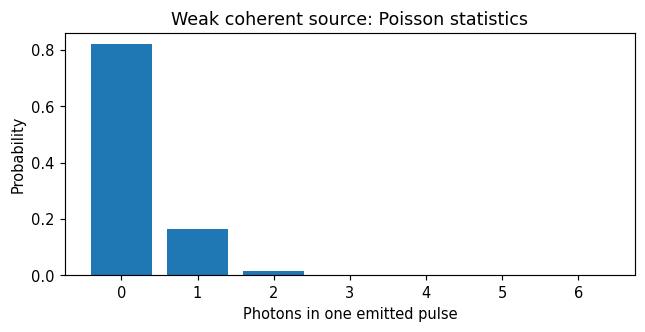

In [23]:
print('Hex bytes:', P['sample_hex'])
print('MSB-first phase bits:', np.unpackbits(parse_hex(P['sample_hex'])))
print('Phase angles (radians):', np.pi*np.unpackbits(parse_hex(P['sample_hex'])))
display(encode_bytes(P['sample_hex']))
poisson_n = np.arange(7)
poisson_p = np.array([np.exp(-P['mu'])*P['mu']**int(n)/math.factorial(int(n)) for n in poisson_n])
display(pd.DataFrame({'photons_per_pulse':poisson_n,'probability':poisson_p}))
fig, ax = plt.subplots(figsize=(7,3)); ax.bar(poisson_n, poisson_p)
ax.set(xlabel='Photons in one emitted pulse',ylabel='Probability',title='Weak coherent source: Poisson statistics')
plt.show()


### Experiment 3: Fiber, all calculations visible

The ledger shows the formula, numerical result and unit for every stage. The summary then distinguishes model probabilities from simulated event counts. The sample arrays are available in `results['Fiber']`; no intermediate propagation or detector calculation is hidden.


In [24]:
results = {}


DPS-QKD: Fiber | none
                                 quantity                                                         formula        value        unit
                               wavelength                                            wavelength_nm * 1e-9 1.550000e-06           m
                               wavenumber                                                     2*pi/lambda 4.053668e+06       rad/m
                         pulse separation                                                      1/clock_hz 1.000000e-09           s
interferometer free-space path difference                   c/clock_hz; divide by group index in material 2.997925e-01           m
                         attenuation loss                                          alpha_dB_per_km * L_km 4.000000e+00          dB
                          connectors loss                                                      input loss 1.000000e+00          dB
                             splices loss                   

,quantity,formula,value,unit
0,wavelength,wavelength_nm * 1e-9,1.550000e-06,m
1,wavenumber,2*pi/lambda,4.053668e+06,rad/m
2,pulse separation,1/clock_hz,1.000000e-09,s
3,interferometer free-space path difference,c/clock_hz; divide by group index in material,2.997925e-01,m
4,attenuation loss,alpha_dB_per_km * L_km,4.000000e+00,dB
5,connectors loss,input loss,1.000000e+00,dB
6,splices loss,splice_count * splice_db,1.000000e-01,dB
7,other fiber loss,input loss,9.000000e-01,dB
8,dispersion RMS broadening,abs(D)*L_km*spectral_sigma_nm,6.800000e+00,ps
9,received pulse RMS width,sqrt(sigma_initial^2 + broadening^2),3.076101e+01,ps


,value
channel,Fiber
fading,none
length_km,20.0
nominal_loss_db,6.0
rytov_variance,0.0
fried_r0_m,inf
fading_blocks,201
block_duration_s,0.000001
duration_s,0.0002
fading_mean,1.0


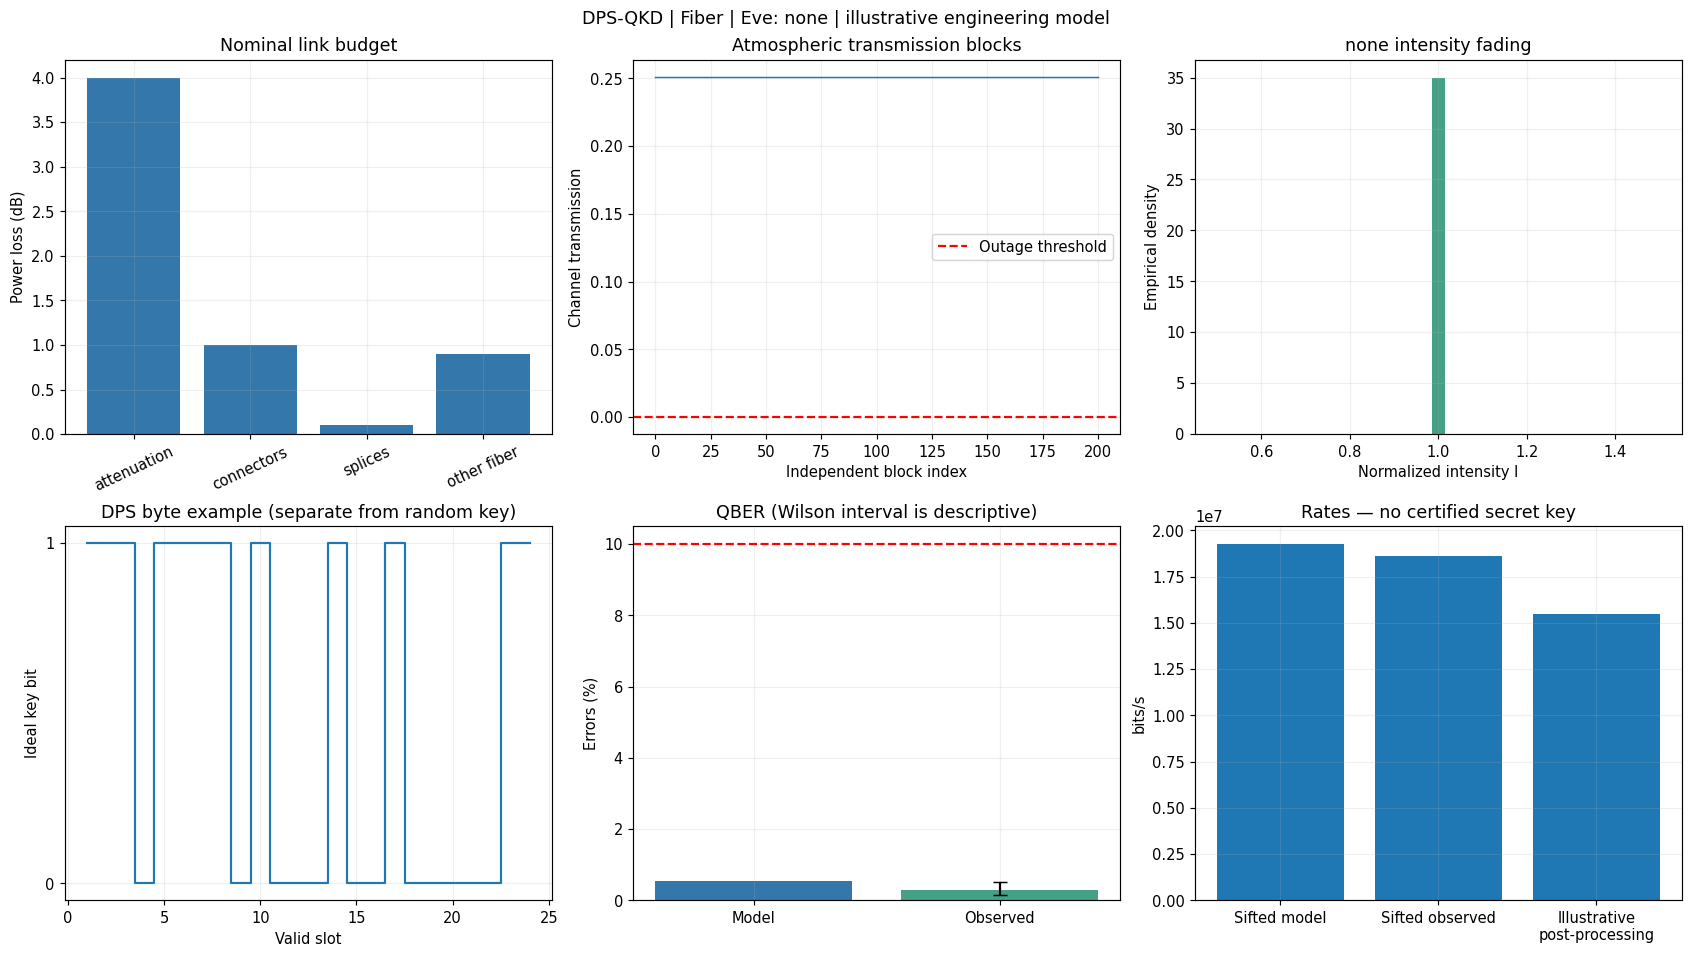

WindowsPath('D:/IIT Class/Project/Submission/QuantumKeyDistribution-DPS/outputs/examples/python/fiber')

In [25]:
cfg = copy.deepcopy(P)
cfg['channel'] = 'Fiber'
r = simulate(cfg)
results['Fiber'] = r
print_report(r)
display(r['calculations'])
display(pd.DataFrame([r['summary']]).T.rename(columns={0:'value'}))
fig = plot_result(r)
plt.show()
export_result(r, 'outputs/examples/python/fiber')


### Experiment 4: FSO-Terrestrial, all calculations visible

The ledger shows the formula, numerical result and unit for every stage. The summary then distinguishes model probabilities from simulated event counts. The sample arrays are available in `results['FSO-Terrestrial']`; no intermediate propagation or detector calculation is hidden.



DPS-QKD: FSO-Terrestrial | none
                                 quantity                                                         formula        value        unit
                               wavelength                                            wavelength_nm * 1e-9 1.550000e-06           m
                               wavenumber                                                     2*pi/lambda 4.053668e+06       rad/m
                         pulse separation                                                      1/clock_hz 1.000000e-09           s
interferometer free-space path difference                   c/clock_hz; divide by group index in material 2.997925e-01           m
                           Rytov variance                                       1.23*Cn2*k^(7/6)*L^(11/6) 7.094955e-01           -
                 Fried coherence diameter                             (0.423*k^2*integral(Cn2 ds))^(-3/5) 5.177975e-02           m
          effective divergence half-angle         

,quantity,formula,value,unit
0,wavelength,wavelength_nm * 1e-9,1.550000e-06,m
1,wavenumber,2*pi/lambda,4.053668e+06,rad/m
2,pulse separation,1/clock_hz,1.000000e-09,s
3,interferometer free-space path difference,c/clock_hz; divide by group index in material,2.997925e-01,m
4,Rytov variance,1.23*Cn2*k^(7/6)*L^(11/6),7.094955e-01,-
5,Fried coherence diameter,(0.423*k^2*integral(Cn2 ds))^(-3/5),5.177975e-02,m
6,effective divergence half-angle,"max(input_urad*1e-6, lambda/(pi*w0))",4.000000e-05,rad
7,beam radius at receiver,sqrt(w0^2 + (theta*L)^2),8.544004e-02,m
8,centered Gaussian aperture capture,1-exp(-2*a^2/w^2),9.354120e-01,-
9,per-axis spot jitter,L * pointing_urad * 1e-6,4.000000e-03,m


,value
channel,FSO-Terrestrial
fading,lognormal
length_km,2.0
nominal_loss_db,2.689971
rytov_variance,0.709495
fried_r0_m,0.05178
fading_blocks,201
block_duration_s,0.000001
duration_s,0.0002
fading_mean,0.815503


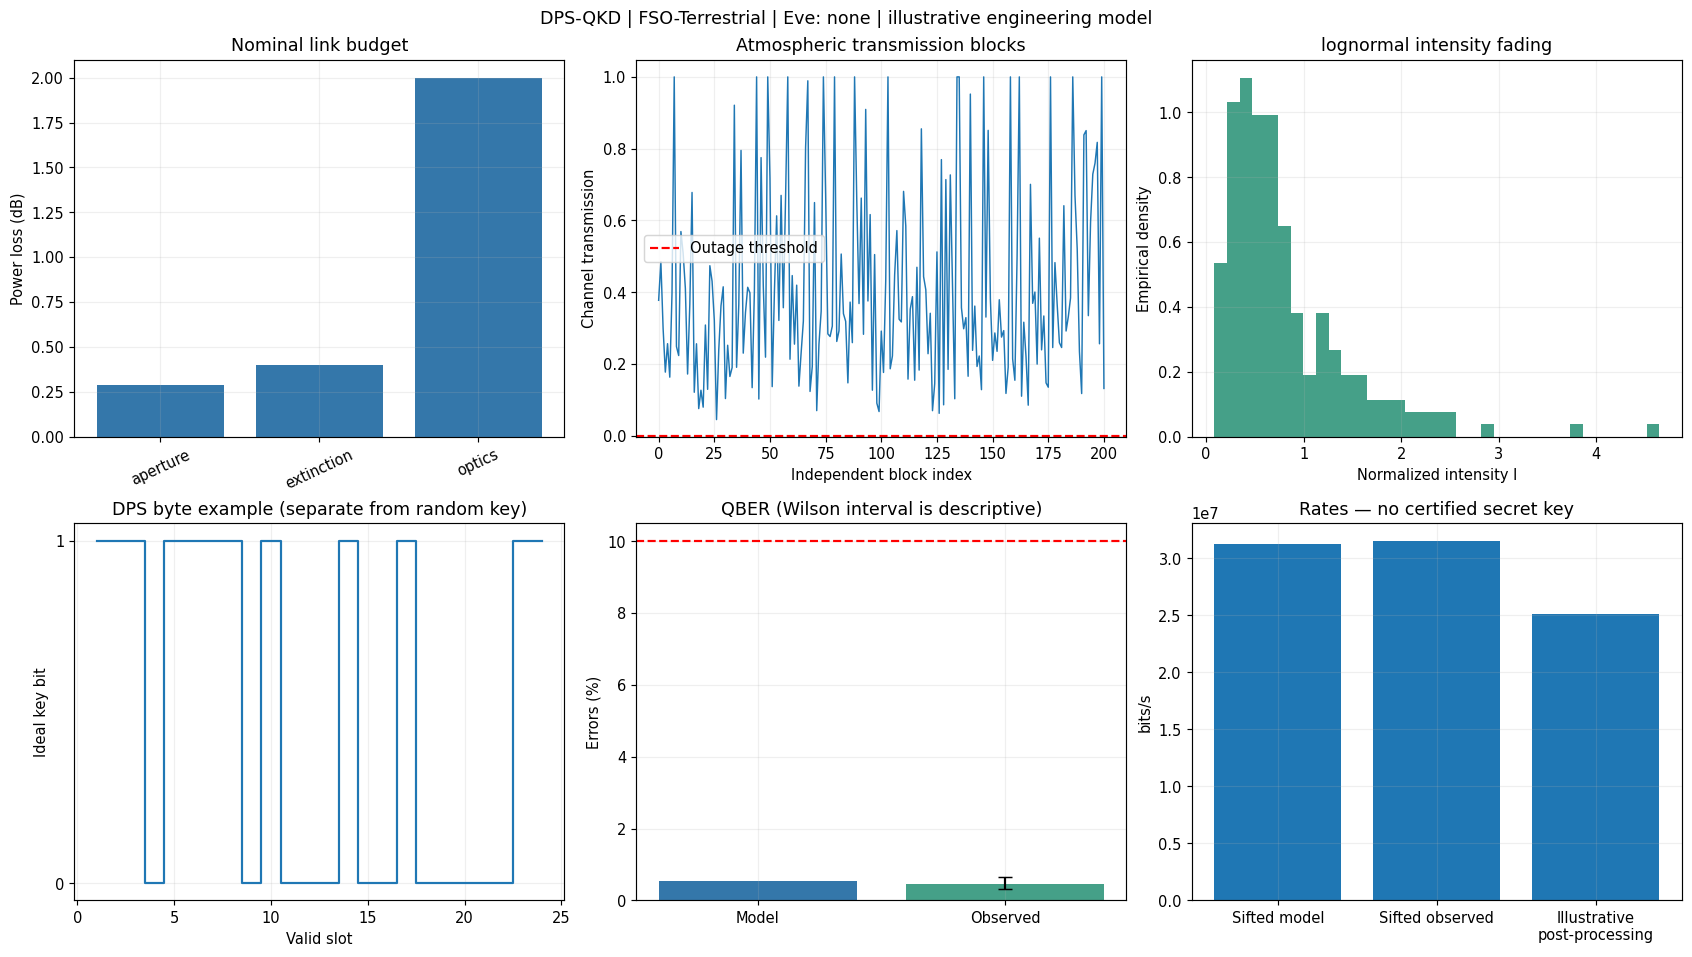

WindowsPath('D:/IIT Class/Project/Submission/QuantumKeyDistribution-DPS/outputs/examples/python/terrestrial')

In [26]:
cfg = copy.deepcopy(P)
cfg['channel'] = 'FSO-Terrestrial'
r = simulate(cfg)
results['FSO-Terrestrial'] = r
print_report(r)
display(r['calculations'])
display(pd.DataFrame([r['summary']]).T.rename(columns={0:'value'}))
fig = plot_result(r)
plt.show()
export_result(r, 'outputs/examples/python/terrestrial')


### Experiment 5: Satellite-Ground, all calculations visible

The ledger shows the formula, numerical result and unit for every stage. The summary then distinguishes model probabilities from simulated event counts. The sample arrays are available in `results['Satellite-Ground']`; no intermediate propagation or detector calculation is hidden.



DPS-QKD: Satellite-Ground | none
                                 quantity                                                         formula        value        unit
                               wavelength                                            wavelength_nm * 1e-9 1.550000e-06           m
                               wavenumber                                                     2*pi/lambda 4.053668e+06       rad/m
                         pulse separation                                                      1/clock_hz 1.000000e-09           s
interferometer free-space path difference                   c/clock_hz; divide by group index in material 2.997925e-01           m
                              slant range                              sqrt(Rs^2-Rg^2*cos(e)^2)-Rg*sin(e) 6.830686e+05           m
             weighted turbulence integral                             trapz(h, Cn2(h)*(h-h_ground)^(5/6)) 5.394390e-10     m^(7/6)
                           Rytov variance        

,quantity,formula,value,unit
0,wavelength,wavelength_nm * 1e-9,1.550000e-06,m
1,wavenumber,2*pi/lambda,4.053668e+06,rad/m
2,pulse separation,1/clock_hz,1.000000e-09,s
3,interferometer free-space path difference,c/clock_hz; divide by group index in material,2.997925e-01,m
4,slant range,sqrt(Rs^2-Rg^2*cos(e)^2)-Rg*sin(e),6.830686e+05,m
5,weighted turbulence integral,"trapz(h, Cn2(h)*(h-h_ground)^(5/6))",5.394390e-10,m^(7/6)
6,Rytov variance,2.25*k^(7/6)*sin(e)^(-11/6)*weighted_integral,1.172804e-01,-
7,slant Cn2 integral,"trapz(h,Cn2)/sin(e)",3.161336e-12,m^(1/3)
8,atmospheric path approximation,(h_top-h_ground)/sin(e),2.828427e+04,m
9,Fried coherence diameter,(0.423*k^2*integral(Cn2 ds))^(-3/5),1.566230e-01,m


,value
channel,Satellite-Ground
fading,lognormal
length_km,683.06862
nominal_loss_db,24.137975
rytov_variance,0.11728
fried_r0_m,0.156623
fading_blocks,201
block_duration_s,0.000001
duration_s,0.0002
fading_mean,0.940678


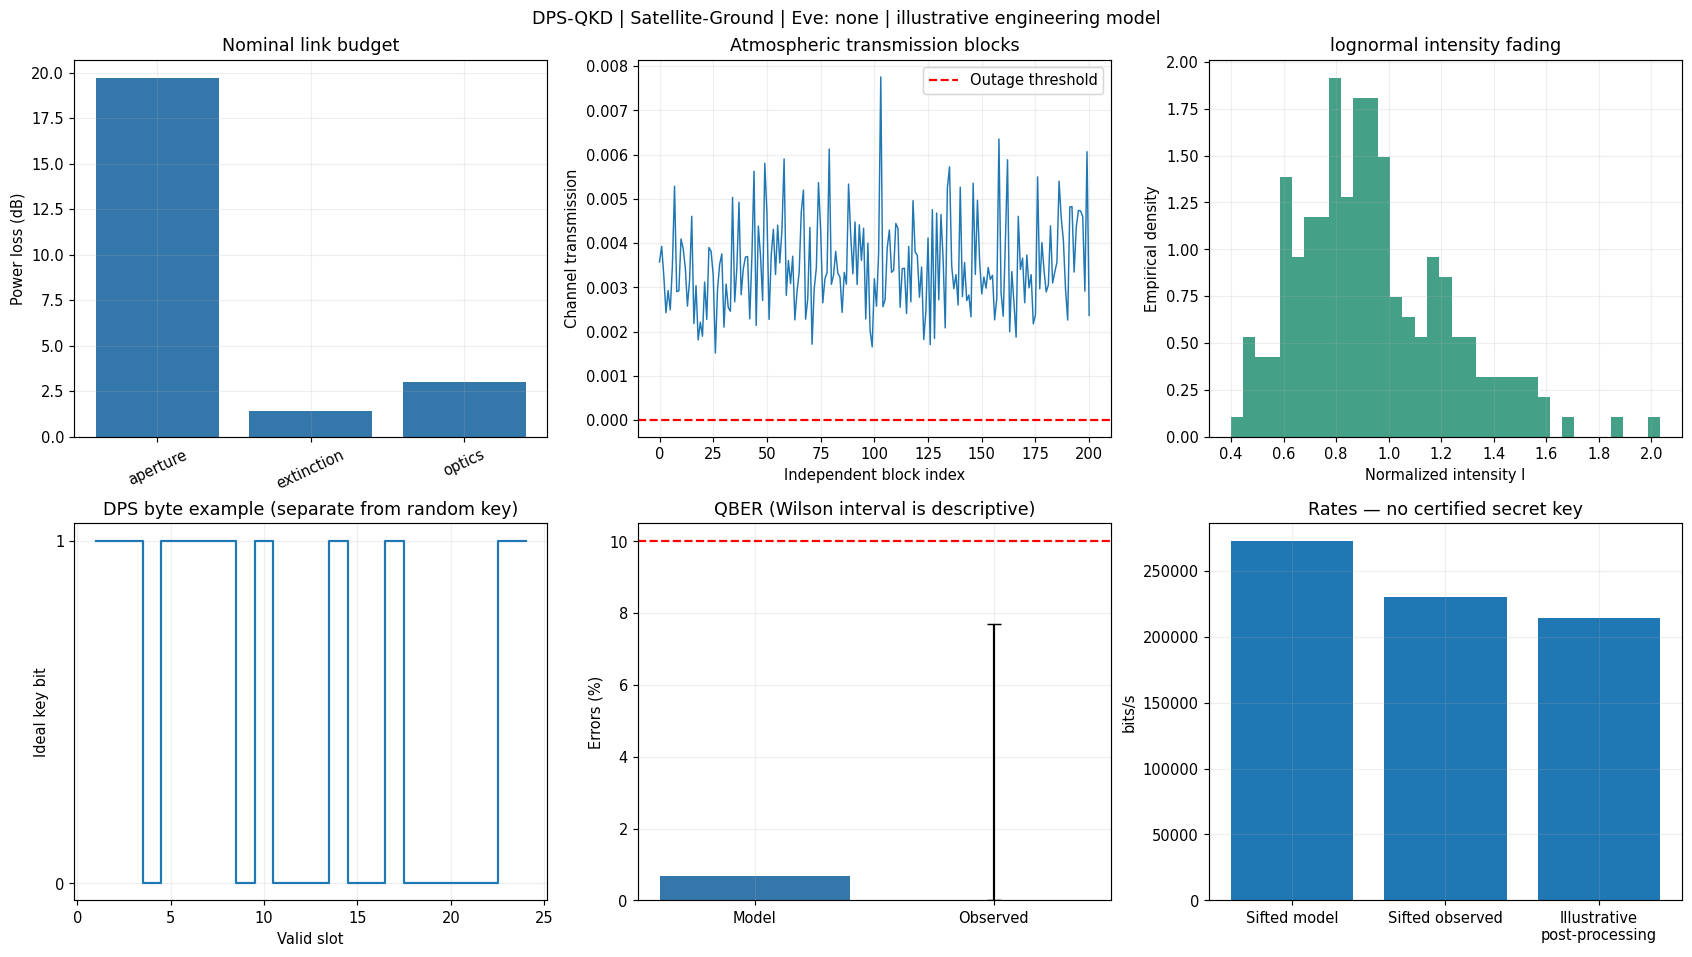

WindowsPath('D:/IIT Class/Project/Submission/QuantumKeyDistribution-DPS/outputs/examples/python/satellite')

In [27]:
cfg = copy.deepcopy(P)
cfg['channel'] = 'Satellite-Ground'
r = simulate(cfg)
results['Satellite-Ground'] = r
print_report(r)
display(r['calculations'])
display(pd.DataFrame([r['summary']]).T.rename(columns={0:'value'}))
fig = plot_result(r)
plt.show()
export_result(r, 'outputs/examples/python/satellite')


The ground profile is sampled in altitude before integration. The next table makes the profile available for independent hand/trapezoidal checks; the entire 2001-point array is retained in the result.

,altitude_m,Cn2_m_minus_2over3
0,0.0,1.727000e-14
100,1000.0,1.393944e-16
200,2000.0,7.117624e-17
300,3000.0,3.664617e-17
400,4000.0,1.945064e-17
500,5000.0,1.199640e-17
600,6000.0,1.033093e-17
700,7000.0,1.179482e-17
800,8000.0,1.424674e-17
900,9000.0,1.613150e-17


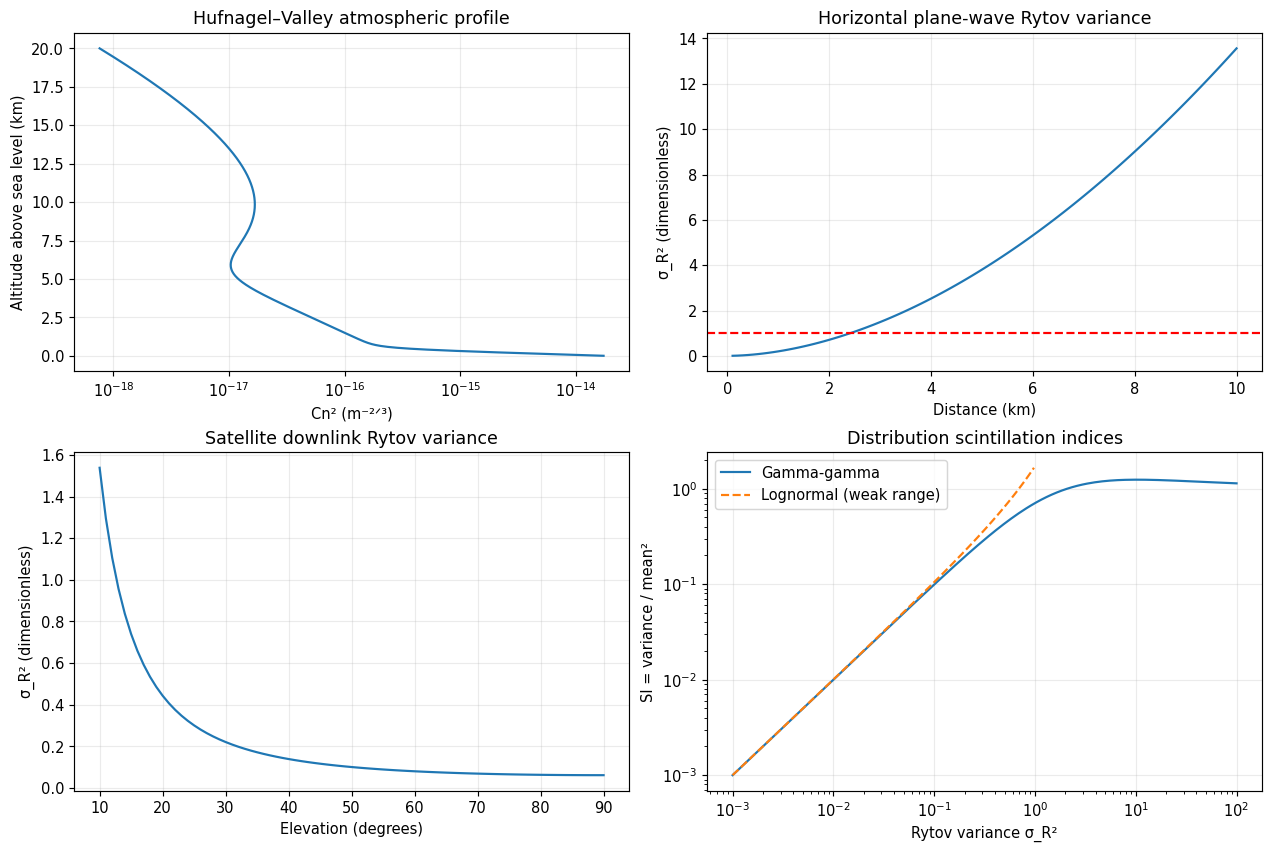

In [28]:
sat = results['Satellite-Ground']['channel']
display(pd.DataFrame({'altitude_m':sat['profile_h'], 'Cn2_m_minus_2over3':sat['profile_cn2']}).iloc[::100])
fig = plot_atmosphere(P)
plt.show()


### Experiment 6: compare all three channels

These default scenarios have different physical distances and apertures; the table compares their stated settings, not identical hardware. Never compare raw bit counts without accounting for simulated duration. A no-error low-count result still has a nonzero uncertainty interval.


,channel,length_km,nominal_loss_db,rytov_variance,mean_channel_eta,detected_sifted_bits,qber_model,qber_observed,sifted_rate_model_bps,illustrative_postprocessing_bps,classroom_status
0,Fiber,20.00000,6.000000,0.000000,0.251189,3718,0.005580,0.002959,1.926423e+07,1.547294e+07,PASS classroom QBER check (not security certif...
1,FSO-Terrestrial,2.00000,2.689971,0.709495,0.413265,6295,0.005557,0.004607,3.128215e+07,2.513606e+07,PASS classroom QBER check (not security certif...
2,Satellite-Ground,683.06862,24.137975,0.117280,0.003506,46,0.006827,0.000000,2.721520e+05,2.137576e+05,INSUFFICIENT TEST DATA


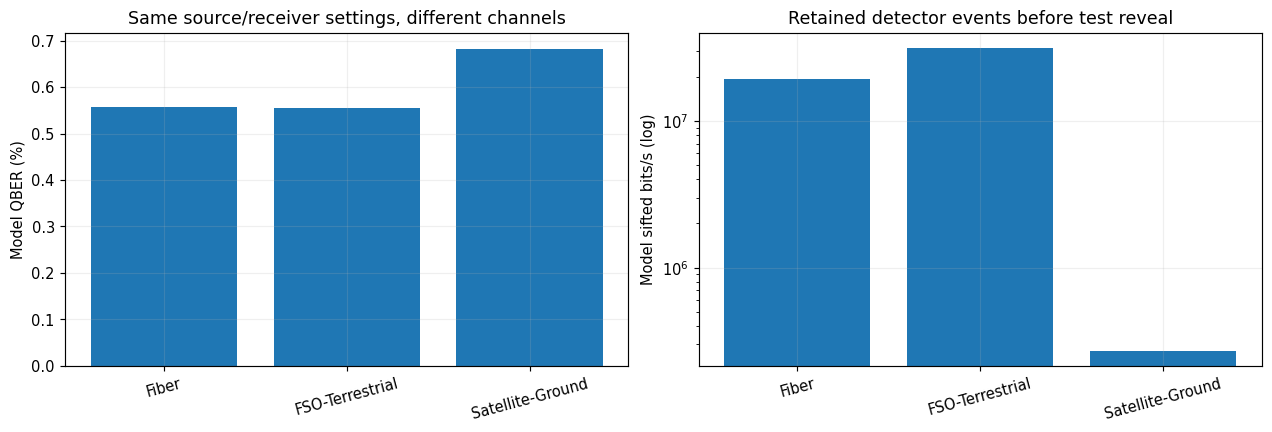

In [29]:
comparison = pd.DataFrame([r['summary'] for r in results.values()])
display(comparison[['channel','length_km','nominal_loss_db','rytov_variance','mean_channel_eta',
                    'detected_sifted_bits','qber_model','qber_observed','sifted_rate_model_bps',
                    'illustrative_postprocessing_bps','classroom_status']])
fig, axes = plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
axes[0].bar(comparison.channel,100*comparison.qber_model)
axes[0].set(ylabel='Model QBER (%)',title='Same source/receiver settings, different channels')
axes[1].bar(comparison.channel,comparison.sifted_rate_model_bps)
axes[1].set(yscale='log',ylabel='Model sifted bits/s (log)',title='Retained detector events before test reveal')
for ax in axes: ax.tick_params(axis='x',rotation=15); ax.grid(alpha=.2)
plt.show()
comparison.to_csv('outputs/examples/python/channel_comparison.csv',index=False)


### Experiment 7: inspect real detector events and sifted strings

`nu0` and `nu1` are mean detected **signal** photons before adding gate noise. `p0` and `p1` are click probabilities after noise. The boolean click columns are random realizations; a retained `bob_bit=-1` means no usable bit. Double clicks are discarded. Bob's retained detector numbers should largely agree with Alice's selected XOR bits.


In [30]:
r = results[P['channel']]
display(r['trace'].head(20))
display(r['trace'].loc[r['trace'].accepted].head(20))
print('First 80 Alice sifted bits:', ''.join(map(str,r['alice_sifted'][:80])))
print('First 80 Bob sifted bits:  ', ''.join(map(str,r['bob_sifted'][:80])))
print('Test sample indices (zero-based Python array indices):',r['test_indices'][:20])
print('Public test size:',r['summary']['test_bits'])
print('Public test QBER:',r['summary']['test_qber'])
print('Test decision:',r['summary']['classroom_status'])


,slot,alice_phase_previous,alice_phase_current,alice_bit,forwarded_bit,eta_previous,eta_current,phase_noise_rad,nu0,nu1,p0,p1,click0,click1,accepted,bob_bit,error,eve_estimate
0,1,1,1,0,0,0.251189,0.251189,-0.028239,0.019353,0.000101,0.019167,0.000101,False,False,False,-1,False,-1
1,2,1,1,0,0,0.251189,0.251189,-0.032503,0.019351,0.000102,0.019166,0.000103,False,False,False,-1,False,-1
2,3,1,1,0,0,0.251189,0.251189,-0.073131,0.019331,0.000123,0.019145,0.000123,False,False,False,-1,False,-1
3,4,1,1,0,0,0.251189,0.251189,-0.071850,0.019332,0.000122,0.019146,0.000122,False,False,False,-1,False,-1
4,5,1,1,0,0,0.251189,0.251189,-0.028013,0.019353,0.000101,0.019167,0.000101,False,False,False,-1,False,-1
5,6,1,1,0,0,0.251189,0.251189,-0.028199,0.019353,0.000101,0.019167,0.000101,False,False,False,-1,False,-1
6,7,1,0,1,1,0.251189,0.251189,-0.039677,0.000105,0.019349,0.000105,0.019163,False,False,False,-1,False,-1
7,8,0,0,0,0,0.251189,0.251189,0.021978,0.019354,0.000100,0.019168,0.000100,False,False,False,-1,False,-1
8,9,0,0,0,0,0.251189,0.251189,0.005381,0.019356,0.000097,0.019171,0.000098,False,False,False,-1,False,-1
9,10,0,0,0,0,0.251189,0.251189,-0.049756,0.019345,0.000109,0.019159,0.000110,False,False,False,-1,False,-1


,slot,alice_phase_previous,alice_phase_current,alice_bit,forwarded_bit,eta_previous,eta_current,phase_noise_rad,nu0,nu1,p0,p1,click0,click1,accepted,bob_bit,error,eve_estimate
38,39,0,1,1,1,0.251189,0.251189,0.029413,0.000101,0.019352,0.000102,0.019167,False,True,True,1,False,-1
44,45,1,1,0,0,0.251189,0.251189,-0.025925,0.019353,0.000101,0.019168,0.000101,True,False,True,0,False,-1
106,107,1,0,1,1,0.251189,0.251189,0.051062,0.000110,0.019344,0.000110,0.019158,False,True,True,1,False,-1
116,117,1,1,0,0,0.251189,0.251189,0.002882,0.019356,0.000097,0.019171,0.000098,True,False,True,0,False,-1
138,139,1,0,1,1,0.251189,0.251189,-0.043108,0.000106,0.019348,0.000107,0.019162,False,True,True,1,False,-1
149,150,0,1,1,1,0.251189,0.251189,0.011191,0.000098,0.019356,0.000098,0.019170,False,True,True,1,False,-1
183,184,1,1,0,0,0.251189,0.251189,-0.059513,0.019339,0.000114,0.019154,0.000115,True,False,True,0,False,-1
232,233,1,1,0,0,0.251189,0.251189,-0.023183,0.019354,0.000100,0.019168,0.000100,True,False,True,0,False,-1
266,267,0,0,0,0,0.251189,0.251189,-0.036443,0.019350,0.000104,0.019164,0.000104,True,False,True,0,False,-1
327,328,0,1,1,1,0.251189,0.251189,-0.045634,0.000107,0.019346,0.000108,0.019161,False,True,True,1,False,-1


First 80 Alice sifted bits: 10101100010100011100001101010111100101110011011011101001001010110100011001110010
First 80 Bob sifted bits:   10101100010100011100001101010111100101110011011011101001001010110100011001110010
Test sample indices (zero-based Python array indices): [ 17252  43106 159468  30497  54563  82309  27366  36475 129318 175039
 110524  14761  77379 117587  79716  11551 100529  31203 162111 124415]
Public test size: 371
Public test QBER: 0.0
Test decision: PASS classroom QBER check (not security certification)


### Experiment 8: compare Eve absent, phase-resend, and beam-split

Use the currently selected channel. Interception is applied to actual pulse phases; beam splitting is applied to optical power. The reported Eve estimate agreement is conditional on her having an estimate and Bob retaining that slot. It is not a security bound.


In [31]:
eve_rows = []
eve_results = {}
for mode in ['none','phase-resend','beam-split']:
    cfg=copy.deepcopy(P); cfg['eve_mode']=mode
    cfg['eve_fraction']=0.7; cfg['eve_tap']=0.7
    er=simulate(cfg); eve_results[mode]=er; eve_rows.append(er['summary'])
display(pd.DataFrame(eve_rows)[['eve_mode','qber_model','qber_observed','sifted_rate_model_bps',
    'eve_signal_qber_expected','eve_estimated_sifted_bits','eve_estimate_agreement']])
er=eve_results['phase-resend']
display(er['trace'][['slot','alice_bit','forwarded_bit','eve_estimate','accepted','bob_bit']].head(30))


,eve_mode,qber_model,qber_observed,sifted_rate_model_bps,eve_signal_qber_expected,eve_estimated_sifted_bits,eve_estimate_agreement
0,none,0.005580,0.002959,1.926423e+07,0.00000,0,NaN
1,phase-resend,0.169264,0.170776,1.926423e+07,0.16425,1818,0.765677
2,beam-split,0.005657,0.004371,5.819574e+06,0.00000,164,1.000000


,slot,alice_bit,forwarded_bit,eve_estimate,accepted,bob_bit
0,1,0,0,-1,False,-1
1,2,0,0,-1,False,-1
2,3,0,0,-1,False,-1
3,4,0,0,0,False,-1
4,5,0,0,-1,False,-1
5,6,0,0,-1,False,-1
6,7,1,1,-1,False,-1
7,8,0,0,-1,False,-1
8,9,0,0,-1,False,-1
9,10,0,0,0,True,0


### Experiment 9: length, elevation and Eve sweeps

Fiber and terrestrial FSO sweep their own path lengths. The satellite sweep changes elevation at fixed altitude. Both Eve sweeps use the selected channel. The other current settings are retained. Curves average probabilities even when few detector events occur, but finite atmospheric sampling still produces fluctuations. For smoother results increase `sweep_slots` and obtain more independent fading blocks.


,sweep,x,x_parameter,qber_model,sifted_rate_model_bps,illustrative_postprocessing_bps,nominal_loss_db,rytov_variance,outage_fraction
0,Fiber,0.000000,fiber_km,0.005486,4.767623e+07,3.835872e+07,2.000000,0.000000,0.000000
1,Fiber,13.333333,fiber_km,0.005553,2.609352e+07,2.096860e+07,4.666667,0.000000,0.000000
2,Fiber,26.666667,fiber_km,0.005596,1.420790e+07,1.140836e+07,7.333333,0.000000,0.000000
3,Fiber,40.000000,fiber_km,0.005634,7.714680e+06,6.190382e+06,10.000000,0.000000,0.000000
4,Fiber,53.333333,fiber_km,0.005679,4.182696e+06,3.353503e+06,12.666667,0.000000,0.000000
5,Fiber,66.666667,fiber_km,0.005750,2.265943e+06,1.814397e+06,15.333333,0.000000,0.000000
6,Fiber,80.000000,fiber_km,0.005875,1.227028e+06,9.803040e+05,18.000000,0.000000,0.000000
7,Fiber,93.333333,fiber_km,0.006102,6.642694e+05,5.285414e+05,20.666667,0.000000,0.000000
8,Fiber,106.666667,fiber_km,0.006519,3.595368e+05,2.839457e+05,23.333333,0.000000,0.000000
9,Fiber,120.000000,fiber_km,0.007289,1.945744e+05,1.515784e+05,26.000000,0.000000,0.000000


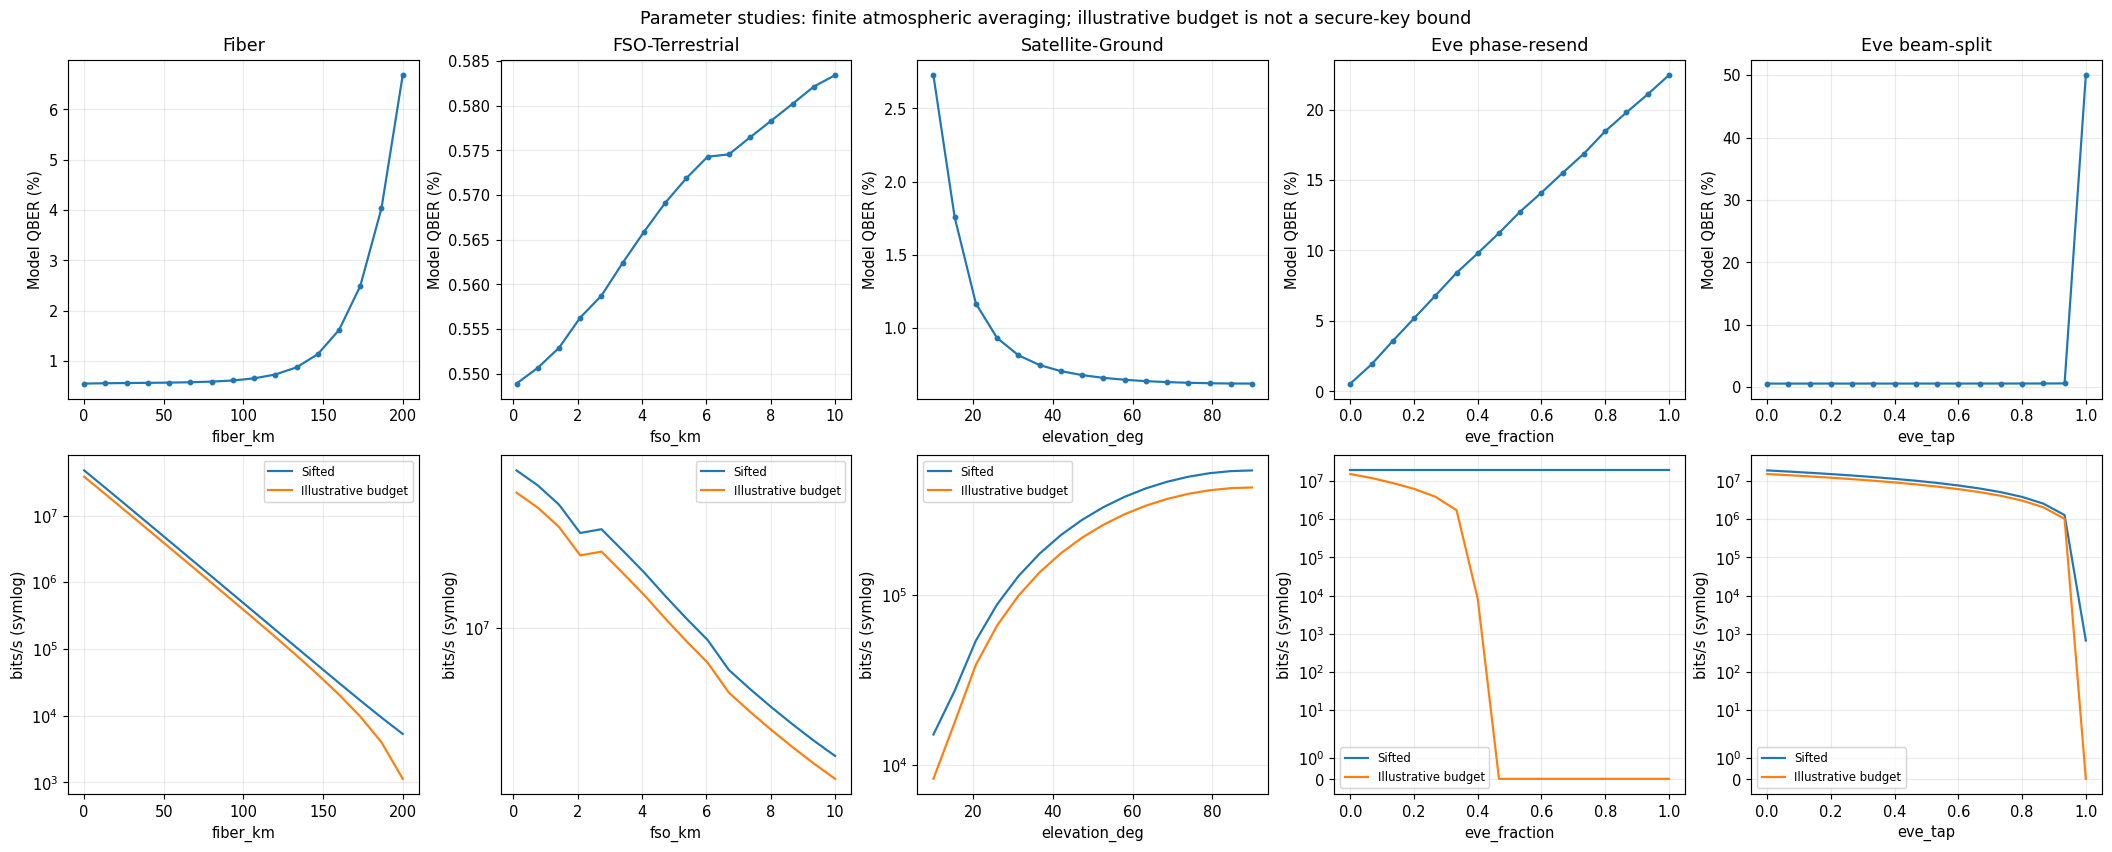

WindowsPath('D:/IIT Class/Project/Submission/QuantumKeyDistribution-DPS/outputs/examples/python/selected_with_sweeps')

In [32]:
sweep_table = run_sweeps(P)
display(sweep_table)
fig = plot_sweeps(sweep_table)
plt.show()
export_result(results[P['channel']], 'outputs/examples/python/selected_with_sweeps', sweep_table)


### Experiment 10: limiting-case checks you can explain by hand

These short assertions verify the model independently of the charts. With no light and no noise, QBER is undefined. With background only it is 50%. With ideal equal-amplitude interference, there are no wrong-port photons and the signal-click probability is 1-exp(-detected mean photons). They also check the satellite geometry at zenith.


In [33]:
ideal=default_parameters()
ideal.update(n_slots=10000,visibility=1.0,phase_sigma_rad=0.0,dark_hz=0.0,background_hz=0.0)
ir=simulate(ideal); c=ir['channel']
detected_mean=ideal['mu']*c['eta0']*ideal['detector_eta']*ideal['coupling_eta']*10**(-ideal['interferometer_loss_db']/10)*c['gate_capture']
assert ir['summary']['qber_model']==0
assert np.isclose(ir['summary']['expected_single_probability'],-np.expm1(-detected_mean))
ideal['mu']=0
assert np.isnan(simulate(ideal)['summary']['qber_observed'])
ideal['dark_hz']=1e7
assert np.isclose(simulate(ideal)['summary']['qber_model'],0.5)
ideal.update(channel='Satellite-Ground',elevation_deg=90.0)
assert np.isclose(channel_model(ideal)['length_m'],ideal['sat_altitude_km']*1000)
print('All notebook limiting-case checks passed. See test_physics.py for the extended checks.')


All notebook limiting-case checks passed. See test_physics.py for the extended checks.


## Part IV — Live runtime controls for every parameter

Click a tab, edit a value, then press a run button. **Run selected** prints every calculation and updates the charts. **Compare all three** runs all propagation models using the current source/receiver settings. **Run parameter/Eve sweeps** updates all five studies. **Export current result** reruns the currently entered configuration and saves CSV/JSON/PNG under `outputs/runtime/python/`.

To use the saved notebook interactively, execute this cell in a live Jupyter kernel. Static previews show saved output but cannot run widget callbacks. If widgets are unavailable, the dictionary examples above provide every setting without a GUI.


In [34]:
controls = runtime_controls(P)


Output()

### Load an exported configuration or save all trial rows

These are optional examples. Remove the leading comments when needed. Load a configuration, validate it, rerun the model, and build a fresh control panel to display its settings. Exported configuration files are compatible with the Octave structure loader.


In [35]:
# P = json.loads(Path('outputs/runtime/python/configuration.json').read_text())
# validate(P)
# current = simulate(P)
# print_report(current)
# controls = runtime_controls(P)
# current['trace'].to_csv('all_detector_trials.csv', index=False)


### Questions for your project discussion

1. Why does common fading primarily reduce counts while differential phase noise increases wrong-port counts?
2. Why is the optical path through the atmosphere much shorter than the satellite slant range?
3. Why does reducing elevation simultaneously change geometric loss, extinction and turbulence?
4. Why can Eve learn information from a beam splitter without directly changing the optical phase error?
5. Why are zero observed errors, a small Wilson interval, and a certified secret key three different claims?
6. How do sample count, block duration, and source clock change what observation period the simulation represents?

Include the exported configuration, assumptions, charts and uncertainty discussion in your submitted report. The source references are linked beside their associated equations in Part I.
